
# Linear & Logistic Regression — From First Principles to Working Code

**A complete, beginner-friendly companion to the "Linear & Logistic Regression" slide deck**
*Phase 2 · Week 5 · Regression & Classification*

This notebook is written for students with **little prior background in machine learning or advanced math**.
Every idea is introduced in plain language first, then written as a formula, then implemented in code — so
you can always connect *why* → *math* → *code*.

### How this notebook is organized

| Part | Topic |
|---|---|
| 0 | Warm-up: what is "learning from data"? |
| 1 | **Linear Regression** — theory, math derivations, EDA, from-scratch training, evaluation, regularization |
| 2 | **Logistic Regression** — theory, math derivations, EDA, from-scratch training, evaluation, regularization, multiclass |
| 3 | Side-by-side synthesis, key takeaways, and practice exercises |

> **Tip:** Run the cells in order from top to bottom. Markdown cells (like this one) explain the *why* and *math*;
> code cells show the *how*, and every code cell that produces a plot is followed by a short discussion of
> what the plot tells us.



## Part 0 — Warm-Up: What Does "Learning From Data" Mean?

Imagine you want to predict the price of a house. You don't know the exact formula the market uses, but you
have historical data: for many houses, you know their size, number of bedrooms, age — and the price they sold for.

**Machine learning for this kind of problem is just this:**

1. Assume a simple mathematical *shape* for the relationship (e.g. "price is a weighted sum of features").
2. Define a **cost function** — a single number that measures "how wrong" the model currently is.
3. Search for the parameters (weights) that make the cost as small as possible. This search process is called **training** or **optimization**.
4. Check how well the trained model performs on data it has never seen (**evaluation**).

This notebook covers **two** of the most fundamental models that follow exactly this recipe:

- **Linear Regression** — predicts a **continuous number** (e.g. price, temperature, salary).
- **Logistic Regression** — predicts a **category / probability** (e.g. spam vs not spam, disease vs no disease).

Despite solving different kinds of problems, you will see that they share almost the *same* mathematical skeleton.
That shared skeleton is one of the biggest "aha" moments in this notebook.


In [4]:
# -----------------------------------------------------------------
# Imports we will use throughout the notebook
# -----------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.datasets import load_iris
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Reproducibility: fixing the random seed means everyone who runs this
# notebook gets the exact same "random" numbers and the exact same results.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Cosmetics
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries loaded. Ready to go!")

Libraries loaded. Ready to go!



---
# Part 1 — Linear Regression

*Predicting continuous outcomes — from a straight line to a full probabilistic and optimization framework.*

## 1.1 The Hypothesis (Model Representation)

Linear regression assumes the target $y$ is a **weighted sum of the input features**, plus one constant
"baseline" term:

$$
h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n
$$

- $\theta_0, \theta_1, \dots, \theta_n$ — the **parameters** (a.k.a. weights). These are the numbers the model *learns*.
- $x_1, \dots, x_n$ — the **input features** (e.g. square footage, number of bedrooms, ...).
- $\theta_0$ is called the **bias** or **intercept** — the predicted value when every feature is 0.

**Vectorized form.** If we define $x_0 = 1$ always, then $h_\theta(x) = \theta^T x$ — a single dot product between
a parameter vector and a feature vector. This is exactly what a spreadsheet's `SUMPRODUCT` does, just with a
fancier name.

**Goal:** find the parameter vector $\theta$ that makes $h_\theta(x^{(i)})$ as close as possible to the true
$y^{(i)}$, for every training example $i = 1, \dots, m$.

## 1.2 Assumptions Behind the Model

Linear regression isn't "assumption-free" — it works best (and its statistics are trustworthy) when:

| # | Assumption | Plain-English meaning |
|---|---|---|
| 1 | **Linearity** | The relationship between features and target really is (approximately) a straight line/plane. |
| 2 | **Independence** | One data point's error doesn't influence another's (no hidden ordering effect). |
| 3 | **Homoscedasticity** | The "spread" of errors is the same for small and large predictions (no funnel shape). |
| 4 | **Normality of errors** | The leftover errors (residuals) are bell-curve shaped — this is what justifies using squared error (next section). |
| 5 | **No multicollinearity** | Features shouldn't be near-duplicates of each other, or the weights become unstable. |
| 6 | **Few/no extreme outliers** | A single wild point can drag the whole fitted line toward it. |

We will actually **check several of these assumptions visually** later in this notebook, once we have a trained model and residuals to look at.

## 1.3 Why Squared Error? A Probabilistic View

Why do we minimize *squared* error instead of, say, absolute error or cubed error? It isn't arbitrary — it falls
directly out of a simple assumption about noise.

Assume every observed target is the "true" linear signal plus random Gaussian (bell-curve) noise:

$$
y^{(i)} = \theta^T x^{(i)} + \varepsilon^{(i)}, \qquad \varepsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)
$$

Equivalently, $y^{(i)}$ given $x^{(i)}$ is normally distributed around the line:

$$
p\big(y^{(i)} \mid x^{(i)}; \theta\big) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{\big(y^{(i)} - \theta^T x^{(i)}\big)^2}{2\sigma^2}\right)
$$

**Maximum Likelihood Estimation (MLE)** says: choose the $\theta$ that makes the data we actually observed as
probable as possible under the model.

**Derivation — from likelihood to mean squared error**

*Step 1 — Likelihood of the full dataset.* Assuming the $m$ examples are independent and identically distributed (i.i.d.), the joint likelihood is a product of each example's density:

$$
L(\theta) = \prod_{i=1}^{m} p\big(y^{(i)} \mid x^{(i)}; \theta\big)
$$

*Step 2 — Take the log.* Products of many small numbers are numerically painful and hard to differentiate, so we take the log (log is monotonically increasing, so it doesn't change *which* $\theta$ is the maximizer):

$$
\ell(\theta) = \log L(\theta) = m\log\frac{1}{\sqrt{2\pi\sigma^2}} \;-\; \frac{1}{2\sigma^2}\sum_{i=1}^{m}\big(y^{(i)} - \theta^T x^{(i)}\big)^2
$$

*Step 3 — Maximizing $\ell(\theta)$ is equivalent to minimizing squared error.* The first term does not depend on
$\theta$ at all, and $\sigma^2 > 0$ is just a positive scaling constant. So maximizing $\ell(\theta)$ is exactly
the same as **minimizing** $\sum_i (y^{(i)} - \theta^T x^{(i)})^2$.

> **Key insight:** "Least squares" isn't an arbitrary convention — it is the mathematically correct thing to do
> *if* you believe your noise is Gaussian. This is why the same idea (MLE) will reappear for logistic regression,
> just with a different noise/label assumption (Bernoulli instead of Gaussian) — producing a *different* loss
> (cross-entropy instead of squared error).

## 1.4 The Cost Function

Averaging the squared errors over all $m$ training examples (and, by convention, dividing by an extra factor of 2)
gives the **Mean Squared Error (MSE) cost function**:

$$
J(\theta) = \frac{1}{2m}\sum_{i=1}^{m}\Big(h_\theta\big(x^{(i)}\big) - y^{(i)}\Big)^2
$$

Why each piece is there:
- **The $\tfrac12$** is pure convenience — it cancels neatly when we differentiate. It does not change *which* $\theta$ minimizes $J$.
- **The $\tfrac1m$** averages the error so the cost is comparable across dataset sizes.
- **Squaring** penalizes large errors disproportionately (an error of 10 hurts 100x more than an error of 1) and keeps $J$ smooth/differentiable everywhere.
- $J(\theta)$ is a **convex quadratic bowl** in $\theta$ — it has exactly **one** global minimum, with no local minima to get stuck in. We will visualize this bowl shortly.

## 1.5 Vectorized Cost & Gradient

Stacking all $m$ examples into a **design matrix** $X \in \mathbb{R}^{m \times (n+1)}$ (one row per example, one
column per feature, plus a column of 1s for the bias) and targets $y \in \mathbb{R}^m$, the cost becomes:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

Differentiating with respect to the vector $\theta$ (using matrix calculus) gives the **gradient**:

$$
\nabla_\theta J(\theta) = \frac{1}{m} X^T (X\theta - y)
$$

**Derivation sketch:**
- Expand $(X\theta - y)^T(X\theta - y) = \theta^T X^T X \theta - 2\theta^T X^T y + y^T y$
- Use the matrix-calculus identities $\partial(\theta^T A \theta)/\partial\theta = 2A\theta$ (for symmetric $A$) and $\partial(b^T\theta)/\partial\theta = b$
- $\nabla_\theta J(\theta) = \frac{1}{m}\left[X^TX\theta - X^Ty\right] = \frac{1}{m}X^T(X\theta - y)$

This single vectorized expression is the engine behind **both** the closed-form solution and gradient descent below.

## 1.6 The Normal Equation (Closed-Form Solution)

Setting the gradient to zero and solving directly for $\theta$:

$$
\theta = (X^TX)^{-1}X^Ty
$$

This gives the *exact* optimum in one step — no iteration, no learning rate to tune. But it has a cost: computing
$(X^TX)^{-1}$ takes roughly $O(n^3)$ time, so it becomes slow once you have many thousands of features, and it
fails outright if $X^TX$ is not invertible (which happens with redundant/perfectly correlated features — Ridge
regression, in section 1.12, fixes this).

## 1.7 Gradient Descent (Iterative Solution)

Taking the partial derivative of $J(\theta)$ with respect to a single parameter $\theta_j$ gives:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}\Big(h_\theta\big(x^{(i)}\big) - y^{(i)}\Big)x_j^{(i)}
$$

Gradient descent repeatedly nudges every $\theta_j$ a small step **opposite** to the gradient (the direction of
steepest ascent, so the negative gradient is the direction of steepest *descent*):

$$
\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j} \quad \text{(simultaneously, for every } j\text{)}
$$

- $\alpha$ is the **learning rate** — it controls the step size. Too small → painfully slow convergence. Too large → the algorithm overshoots and can even diverge.
- **"Simultaneous update"** means every $\theta_j$ must be updated using the *old* $\theta$ values, not the partially-updated ones — otherwise later partial derivatives would be computed against an inconsistent parameter vector.

We now stop talking and start **coding**: we'll build a realistic house-price dataset, explore it, and then
implement gradient descent and the normal equation from scratch.


## 1.8 Building a Dataset: House Price Predictor

Real housing datasets (like the old "Boston Housing" set) are increasingly avoided because of ethical concerns
baked into some of their columns. Instead, we'll build our **own realistic synthetic house-price dataset** --
this has a big teaching advantage: because *we* generate the data, we know the *true* underlying relationship,
so later we can check whether our trained model actually recovers it.

We'll simulate 500 houses with these features:
- `sqft` -- living area in square feet
- `bedrooms` -- number of bedrooms
- `bathrooms` -- number of bathrooms
- `age_years` -- age of the house in years
- `dist_to_city_km` -- distance to city center in kilometers
- `garage_spaces` -- number of garage spaces

The target `price` is generated as a **true linear combination of these features plus Gaussian noise** -- i.e.
we are constructing data that satisfies the exact probabilistic model from section 1.3, on purpose.

In [5]:
n_samples = 500

sqft = np.random.normal(1800, 500, n_samples).clip(500, 4500)
bedrooms = np.random.randint(1, 4, n_samples) + (sqft > 2400).astype(int)  # correlated with sqft on purpose
bathrooms = np.round(np.random.normal(1.5, 0.6, n_samples) + 0.0008 * sqft, 1).clip(1, 5)
age_years = np.random.uniform(0, 60, n_samples)
dist_to_city_km = np.random.exponential(8, n_samples).clip(0.2, 40)
garage_spaces = np.random.randint(0, 4, n_samples)

# The TRUE (unknown-to-the-model) relationship we are trying to recover:
true_theta = {
    "bias": 15000,
    "sqft": 120,
    "bedrooms": 8000,
    "bathrooms": 6000,
    "age_years": -450,
    "dist_to_city_km": -2200,
    "garage_spaces": 4000,
}

noise = np.random.normal(0, 15000, n_samples)  # Gaussian noise -> justifies MSE, per section 1.3

price = (
    true_theta["bias"]
    + true_theta["sqft"] * sqft
    + true_theta["bedrooms"] * bedrooms
    + true_theta["bathrooms"] * bathrooms
    + true_theta["age_years"] * age_years
    + true_theta["dist_to_city_km"] * dist_to_city_km
    + true_theta["garage_spaces"] * garage_spaces
    + noise
).clip(20000, None)

housing = pd.DataFrame({
    "sqft": sqft.round(0),
    "bedrooms": bedrooms,
    "bathrooms": bathrooms,
    "age_years": age_years.round(1),
    "dist_to_city_km": dist_to_city_km.round(2),
    "garage_spaces": garage_spaces,
    "price": price.round(0),
})

print(f"Dataset shape: {housing.shape}")
housing.head()

Dataset shape: (500, 7)


,sqft,bedrooms,bathrooms,age_years,dist_to_city_km,garage_spaces,price
0,2048.0,2,2.9,32.1,1.45,1,286677.0
1,1731.0,2,3.0,5.8,17.09,2,204610.0
2,2124.0,3,3.3,27.0,4.46,1,287425.0
3,2562.0,4,3.3,45.4,1.42,0,335257.0
4,1683.0,1,4.0,20.9,0.20,0,233633.0


### Exploratory Data Analysis (EDA) -- Linear Regression Dataset

Before training anything, we should always **look at the data first**. EDA answers questions like:
*Are there missing values? What ranges do features take? Are any features correlated with each other
(remember assumption #5)? Does the target look roughly linear in each feature?*

In [6]:
housing.info()
print()
housing.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sqft             500 non-null    float64
 1   bedrooms         500 non-null    int64  
 2   bathrooms        500 non-null    float64
 3   age_years        500 non-null    float64
 4   dist_to_city_km  500 non-null    float64
 5   garage_spaces    500 non-null    int64  
 6   price            500 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 27.5 KB



,count,mean,std,min,25%,50%,75%,max
sqft,500.0,1804.09000,488.661197,500.0,1449.75,1806.50,2118.50,3726.0
bedrooms,500.0,2.12200,0.888084,1.0,1.00,2.00,3.00,4.0
bathrooms,500.0,2.95440,0.700844,1.0,2.50,2.90,3.40,5.0
age_years,500.0,30.24060,17.454097,0.2,14.95,30.65,45.75,59.9
dist_to_city_km,500.0,7.73738,7.414593,0.2,2.58,5.43,10.82,40.0
garage_spaces,500.0,1.47600,1.147195,0.0,0.00,1.00,3.00,3.0
price,500.0,242275.31400,68472.353165,58343.0,191617.75,243703.00,286438.75,493524.0


In [7]:
# Check for missing values (a real dataset would very likely have some!)
print("Missing values per column:")
print(housing.isna().sum())

Missing values per column:
sqft               0
bedrooms           0
bathrooms          0
age_years          0
dist_to_city_km    0
garage_spaces      0
price              0
dtype: int64


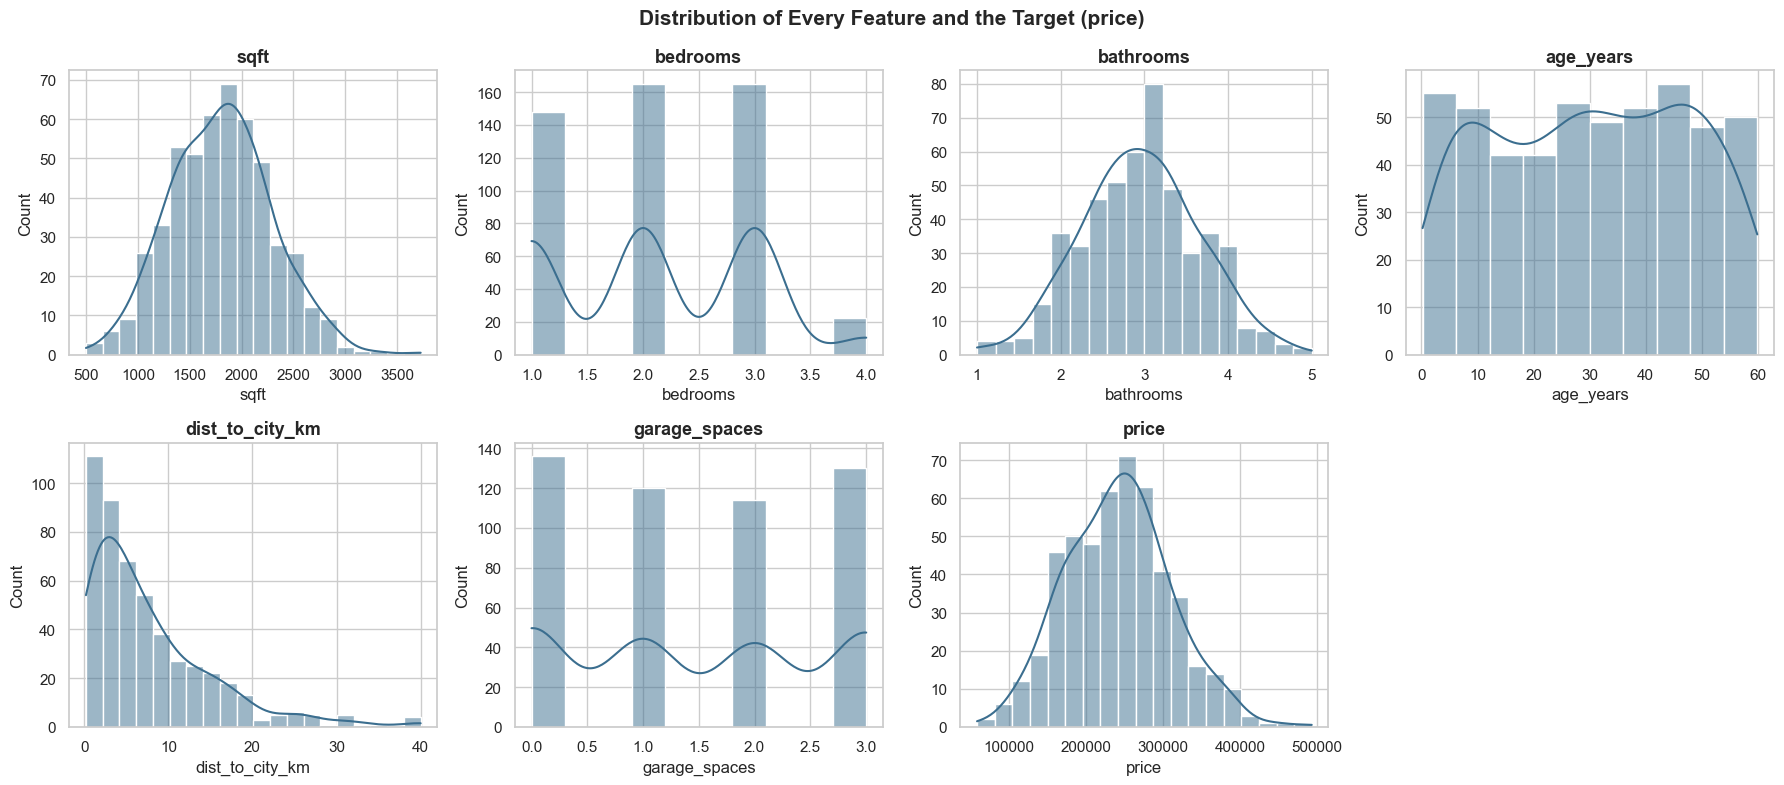

In [8]:
# Distribution of every numeric column, including the target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, col in enumerate(housing.columns):
    sns.histplot(housing[col], kde=True, ax=axes[i], color="#3B6E8F")
    axes[i].set_title(col)
for j in range(len(housing.columns), len(axes)):
    axes[j].axis("off")
plt.suptitle("Distribution of Every Feature and the Target (price)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

**Reading the histograms:** `sqft`, `bathrooms`, and `age_years` look roughly bell-shaped or uniform -- nothing
alarming. `dist_to_city_km` is right-skewed (long tail of far-away houses) -- common for distance-like features.
`price` itself looks roughly bell-shaped, which is reassuring given our Gaussian-noise construction.

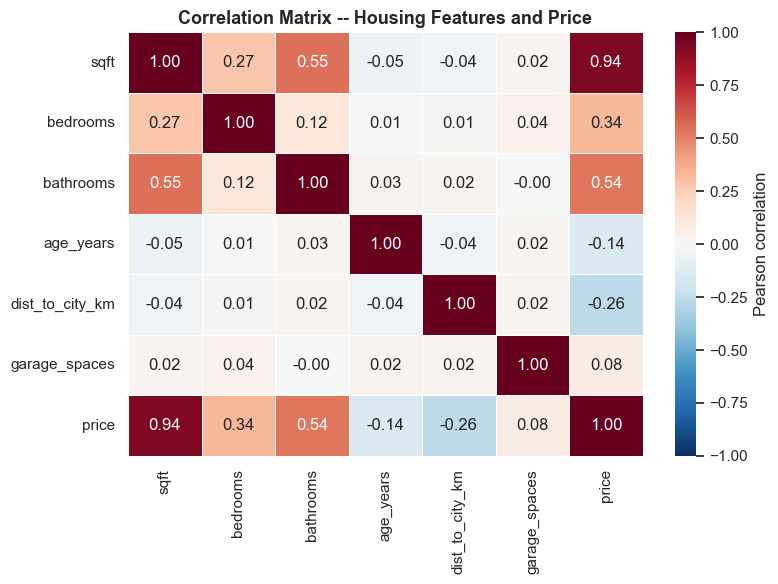

In [9]:
# Correlation heatmap - checks assumption #5 (no multicollinearity) at a glance
plt.figure(figsize=(8, 6))
corr = housing.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Pearson correlation"})
plt.title("Correlation Matrix -- Housing Features and Price")
plt.tight_layout()
plt.show()

**Reading the heatmap:** `sqft` correlates strongly with `price` (as expected -- bigger houses cost more), and it
*also* correlates fairly strongly with `bedrooms` and `bathrooms` -- we engineered that on purpose. This
is a real-world pattern (bigger houses tend to have more rooms) and it's a mild case of **multicollinearity**
(assumption #5). We'll revisit this with Ridge/Lasso regularization in section 1.18, and quantify it properly
with the **Variance Inflation Factor (VIF)** in section 1.17.

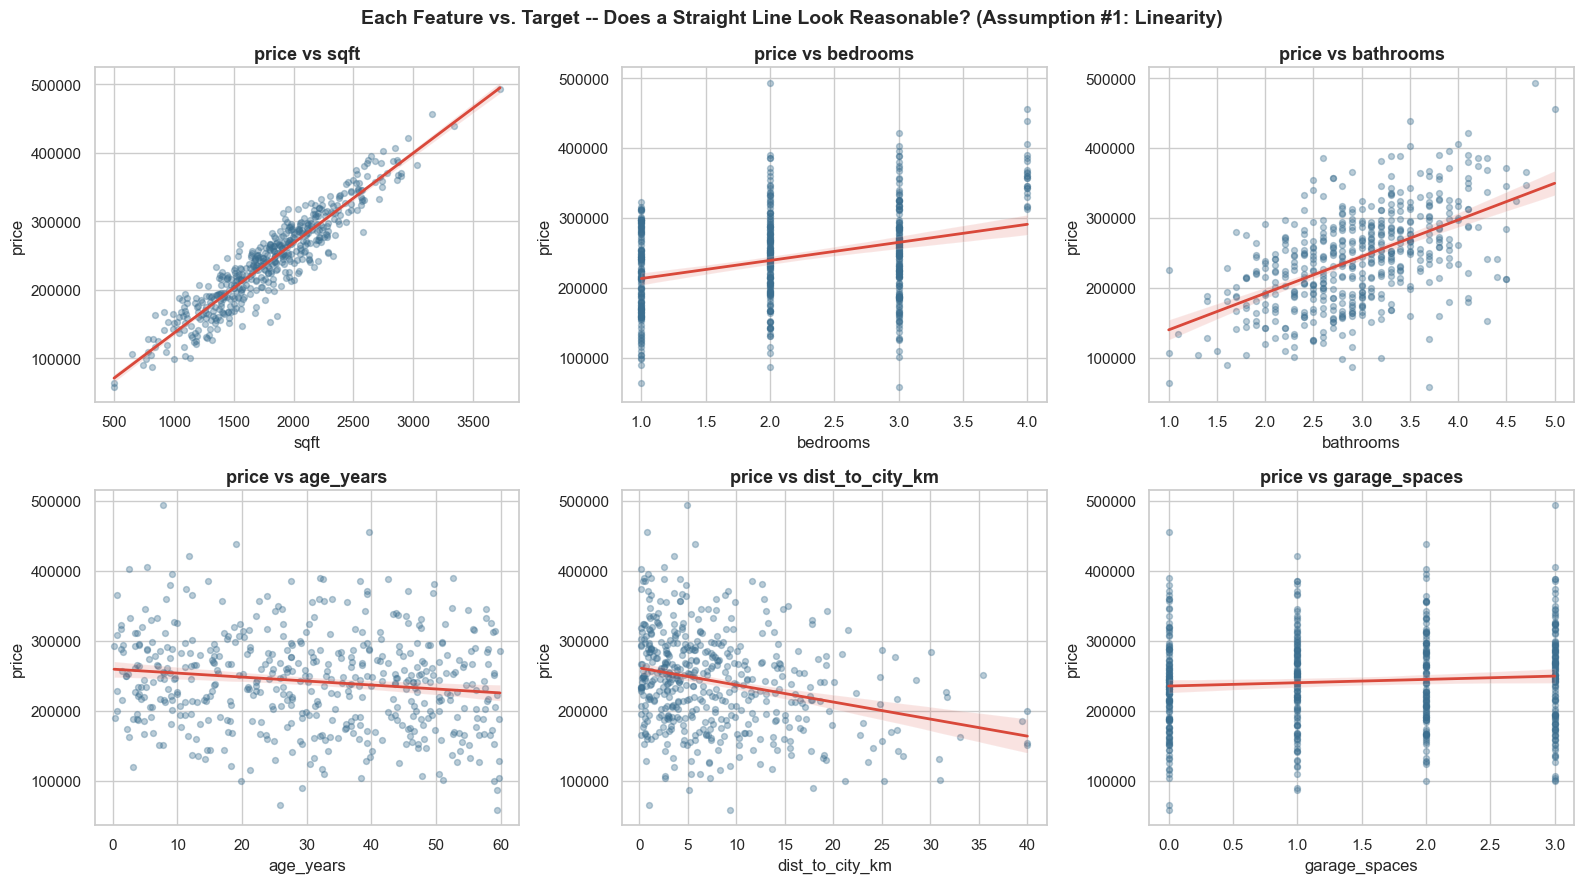

In [10]:
# Scatter plot of every feature against price, with a linear trend line overlaid
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
features = ["sqft", "bedrooms", "bathrooms", "age_years", "dist_to_city_km", "garage_spaces"]
for i, col in enumerate(features):
    sns.regplot(x=housing[col], y=housing["price"], ax=axes[i],
                scatter_kws={"alpha": 0.35, "s": 18, "color": "#3B6E8F"},
                line_kws={"color": "#D9483A", "linewidth": 2})
    axes[i].set_title(f"price vs {col}")
plt.suptitle("Each Feature vs. Target -- Does a Straight Line Look Reasonable? (Assumption #1: Linearity)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Reading these scatter plots:** `sqft`, `bedrooms`, `bathrooms`, and `garage_spaces` all show a clear *positive*
linear trend with price. `age_years` and `dist_to_city_km` show a *negative* trend (older / farther-away houses
are cheaper). None of the relationships look obviously curved (e.g., U-shaped) -- this is a good sanity check that
the **linearity assumption** is reasonable here, which makes sense since we built the data that way.


## 1.9 Preprocessing: Train/Test Split & Feature Scaling

Two crucial steps before training:

1. **Train/test split.** We hold out a portion of the data (the *test set*) that the model never sees during
   training. This is the only honest way to estimate how the model will perform on brand-new houses.
2. **Feature scaling (standardization).** Our features live on wildly different scales -- `sqft` is in the
   thousands, `bathrooms` is a small decimal. Gradient descent takes a step of the *same* relative size in every
   direction, so unscaled features make the cost bowl (section 1.4) very elongated, and gradient descent
   zig-zags slowly instead of moving straight to the minimum. Standardizing each feature to mean 0, standard
   deviation 1 fixes this. (The Normal Equation doesn't need this since it solves for the exact optimum regardless
   of scale, but gradient descent benefits enormously from it.)


In [11]:
feature_cols = ["sqft", "bedrooms", "bathrooms", "age_years", "dist_to_city_km", "garage_spaces"]
X = housing[feature_cols].values
y = housing["price"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled = scaler.transform(X_test)          # re-use the same scaling on test data

print(f"Training examples: {X_train.shape[0]}, Test examples: {X_test.shape[0]}")
print(f"Feature means after scaling (should be ~0): {X_train_scaled.mean(axis=0).round(3)}")
print(f"Feature stds after scaling (should be ~1):  {X_train_scaled.std(axis=0).round(3)}")

Training examples: 400, Test examples: 100
Feature means after scaling (should be ~0): [-0.  0.  0.  0. -0.  0.]
Feature stds after scaling (should be ~1):  [1. 1. 1. 1. 1. 1.]


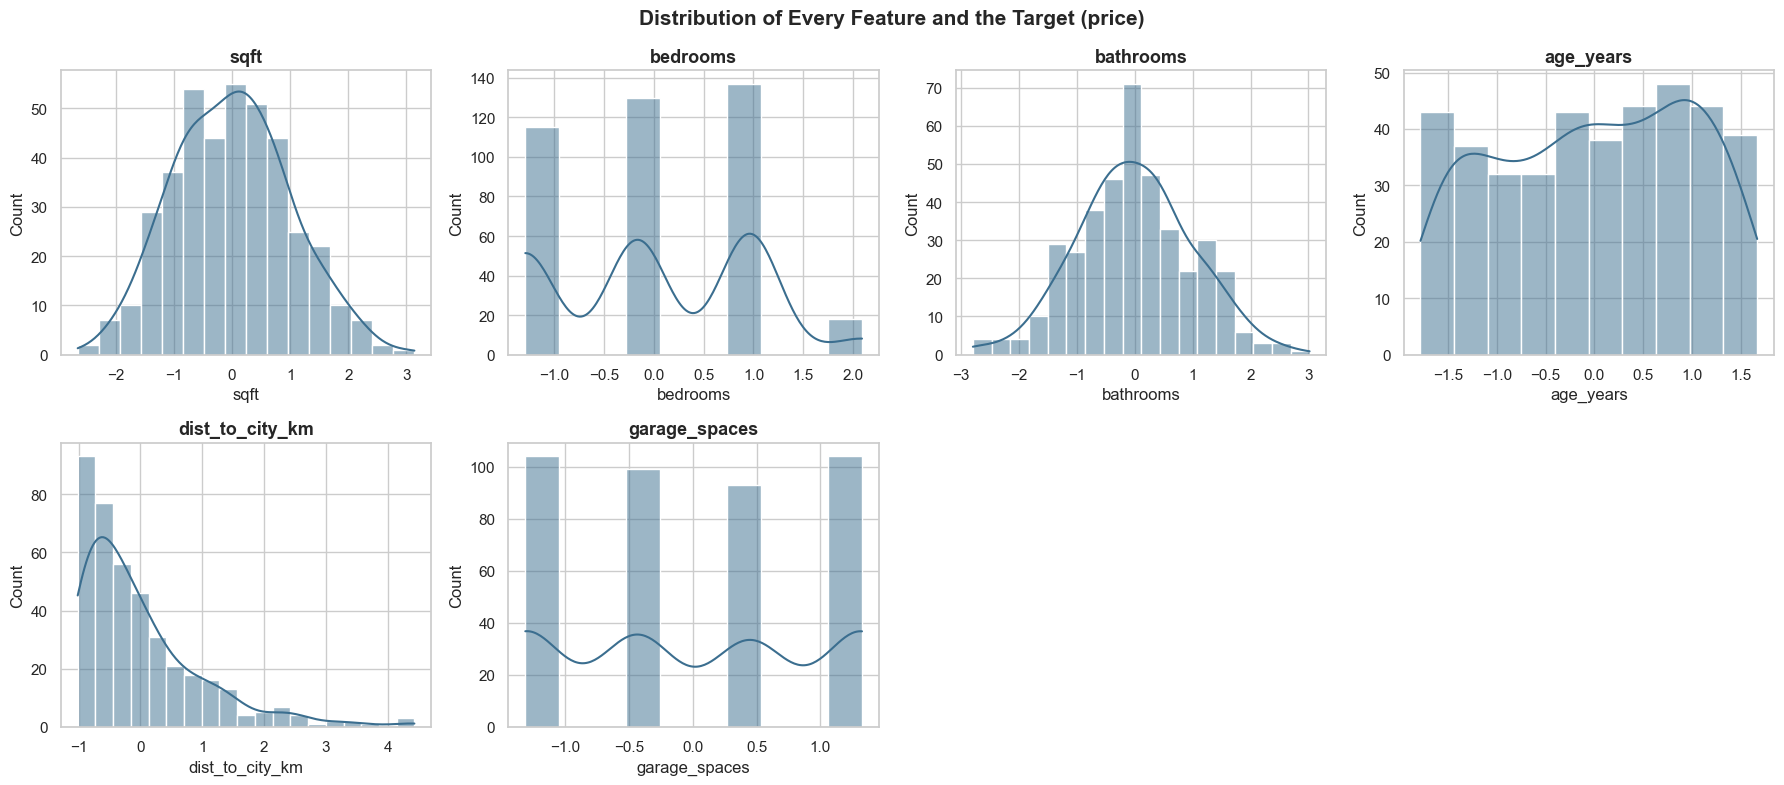

In [ ]:
#After Normalization
pd_x_normalized = pd.DataFrame({
    "sqft": X_train_scaled[:,0],
    "bedrooms": X_train_scaled[:,1],
    "bathrooms": X_train_scaled[:,2],
    "age_years": X_train_scaled[:,3],
    "dist_to_city_km": X_train_scaled[:,4],
    "garage_spaces": X_train_scaled[:,5],
})


# Distribution of every numeric column, including the target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for i, col in enumerate(pd_x_normalized.columns):
    sns.histplot(pd_x_normalized[col], kde=True, ax=axes[i], color="#3B6E8F")
    axes[i].set_title(col)
for j in range(len(pd_x_normalized.columns), len(axes)):
    axes[j].axis("off")
plt.suptitle("Distribution of Every Feature and the Target (price)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


## 1.10 From-Scratch Implementation: Cost Function & Gradient Descent

Now we translate sections 1.4-1.7 directly into code. Notice how closely the code mirrors the math:
`h_theta` is $h_\theta(x) = X\theta$, `compute_cost` is $J(\theta)$, and `gradient_descent` repeats the update
rule $\theta := \theta - \alpha \nabla_\theta J(\theta)$.


In [9]:
def add_bias_column(X):
    # Prepend a column of 1s so that theta[0] acts as the bias/intercept.
    return np.c_[np.ones((X.shape[0], 1)), X]


def h_theta(X_b, theta):
    # The linear regression hypothesis: h_theta(x) = X . theta  (vectorized).
    return X_b @ theta


def compute_cost(X_b, y, theta):
    # Mean-Squared-Error cost function J(theta), as derived in section 1.4.
    m = len(y)
    errors = h_theta(X_b, theta) - y
    return (1 / (2 * m)) * np.sum(errors ** 2)


def gradient_descent(X_b, y, theta, alpha, n_iterations):
    # Batch gradient descent, as derived in section 1.7:
    #     theta := theta - alpha * (1/m) * X^T (X.theta - y)
    # Returns the final theta and the full cost history (for plotting convergence).
    m = len(y)
    cost_history = np.zeros(n_iterations)
    for it in range(n_iterations):
        errors = h_theta(X_b, theta) - y
        gradient = (1 / m) * (X_b.T @ errors)
        theta = theta - alpha * gradient          # simultaneous update (vectorized => automatic)
        cost_history[it] = compute_cost(X_b, y, theta)
    return theta, cost_history


# Prepare the bias-augmented design matrix
X_train_b = add_bias_column(X_train_scaled)
X_test_b = add_bias_column(X_test_scaled)

# Train!
theta_init = np.zeros(X_train_b.shape[1])
alpha = 0.1
n_iterations = 500

theta_gd, cost_history = gradient_descent(X_train_b, y_train, theta_init, alpha, n_iterations)

print("Learned parameters (theta) via Gradient Descent:")
for name, val in zip(["bias"] + feature_cols, theta_gd):
    print(f"  {name:>17s}: {val:>12.2f}")
print(f"\nFinal training cost J(theta): {cost_history[-1]:,.2f}")

Learned parameters (theta) via Gradient Descent:
               bias:    241825.71
               sqft:     59423.87
           bedrooms:      6009.49
          bathrooms:      4393.01
          age_years:     -7546.20
    dist_to_city_km:    -16146.28
      garage_spaces:      5094.64

Final training cost J(theta): 104,063,265.89


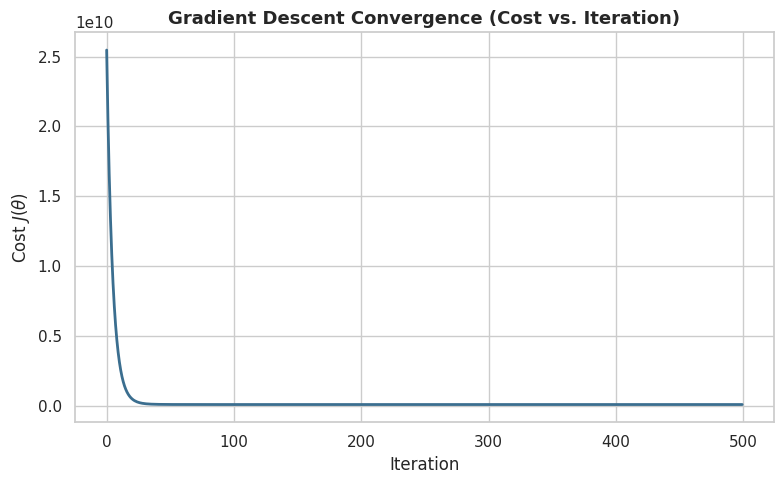

In [10]:
# Plot cost vs. iteration -- the single most important "is training working?" plot
plt.figure(figsize=(8, 5))
plt.plot(range(n_iterations), cost_history, color="#3B6E8F", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel(r"Cost $J(\theta)$")
plt.title("Gradient Descent Convergence (Cost vs. Iteration)")
plt.tight_layout()
plt.show()


**Reading this plot:** the cost drops steeply at first, then flattens out -- this is the classic shape of a
well-behaved gradient descent run. It confirms two things at once: (1) $\alpha = 0.1$ was a reasonable learning
rate, and (2) 500 iterations was enough to (nearly) converge, since the curve has gone essentially flat by the end.



## 1.11 The Cost "Bowl" -- Visualizing Convexity

Section 1.4 claimed $J(\theta)$ is a convex bowl with one global minimum. Let's actually *see* this by fixing
every parameter at its trained value except two, and sweeping those two across a grid.


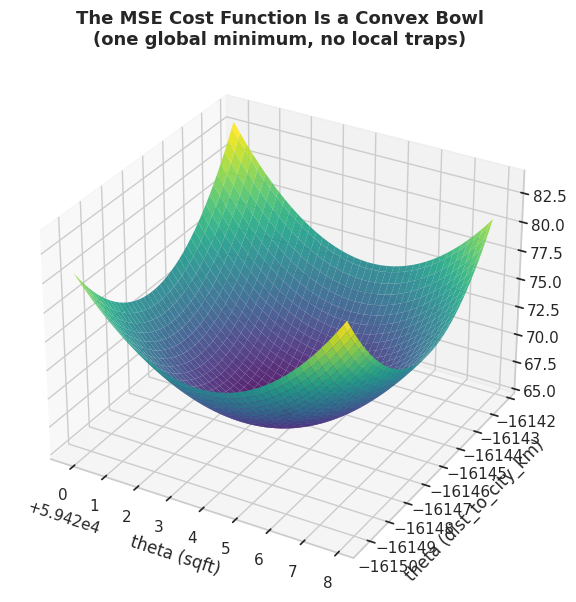

In [11]:
# Pick the two most influential features (by |theta|) to visualize the cost surface
influential_idx = np.argsort(-np.abs(theta_gd[1:]))[:2] + 1  # +1 to skip bias
i1, i2 = influential_idx
names = (["bias"] + feature_cols)
name1, name2 = names[i1], names[i2]

span1 = np.linspace(theta_gd[i1] - 4, theta_gd[i1] + 4, 80)
span2 = np.linspace(theta_gd[i2] - 4, theta_gd[i2] + 4, 80)
Theta1, Theta2 = np.meshgrid(span1, span2)
Costs = np.zeros_like(Theta1)

theta_probe = theta_gd.copy()
for a in range(Theta1.shape[0]):
    for b in range(Theta1.shape[1]):
        theta_probe[i1] = Theta1[a, b]
        theta_probe[i2] = Theta2[a, b]
        Costs[a, b] = compute_cost(X_train_b, y_train, theta_probe)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(Theta1, Theta2, Costs, cmap="viridis", alpha=0.9, linewidth=0)
ax.scatter([theta_gd[i1]], [theta_gd[i2]], [compute_cost(X_train_b, y_train, theta_gd)],
           color="red", s=60, label="Trained minimum")
ax.set_xlabel(f"theta ({name1})")
ax.set_ylabel(f"theta ({name2})")
ax.set_zlabel("Cost J(theta)", labelpad=12)
ax.set_title("The MSE Cost Function Is a Convex Bowl\n(one global minimum, no local traps)")
fig.subplots_adjust(left=0.05, right=0.92)
plt.show()


**Reading this plot:** no matter which two parameters we slice on, the surface is a smooth, single-bottomed bowl.
That's exactly why gradient descent is guaranteed to find the best solution here -- there's nowhere else for it
to get "stuck."

## 1.12 The Normal Equation -- Closed-Form Check

Let's solve for $\theta$ directly using the formula from section 1.6, and confirm it agrees with gradient descent.


In [12]:
def normal_equation(X_b, y):
    # theta = (X^T X)^-1 X^T y  -- the exact, one-shot solution from section 1.6.
    return np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y


theta_normal_eq = normal_equation(X_train_b, y_train)

comparison = pd.DataFrame({
    "Parameter": ["bias"] + feature_cols,
    "Gradient Descent": theta_gd.round(2),
    "Normal Equation": theta_normal_eq.round(2),
})
comparison

,Parameter,Gradient Descent,Normal Equation
0,bias,241825.71,241825.71
1,sqft,59423.87,59423.87
2,bedrooms,6009.49,6009.49
3,bathrooms,4393.01,4393.01
4,age_years,-7546.20,-7546.20
5,dist_to_city_km,-16146.28,-16146.28
6,garage_spaces,5094.64,5094.64



**Reading this table:** the two methods land on (essentially) the same parameters -- small differences are just
because gradient descent hasn't *fully* converged in 500 iterations. This is a nice confirmation that our
from-scratch gradient descent code is correct: two completely different optimization strategies agree.



## 1.13 Learning Rate Experiments

Section 1.7 warned that the learning rate $\alpha$ is a critical dial: too small is slow, too large diverges.
Let's see this directly by running gradient descent with several different values of $\alpha$.


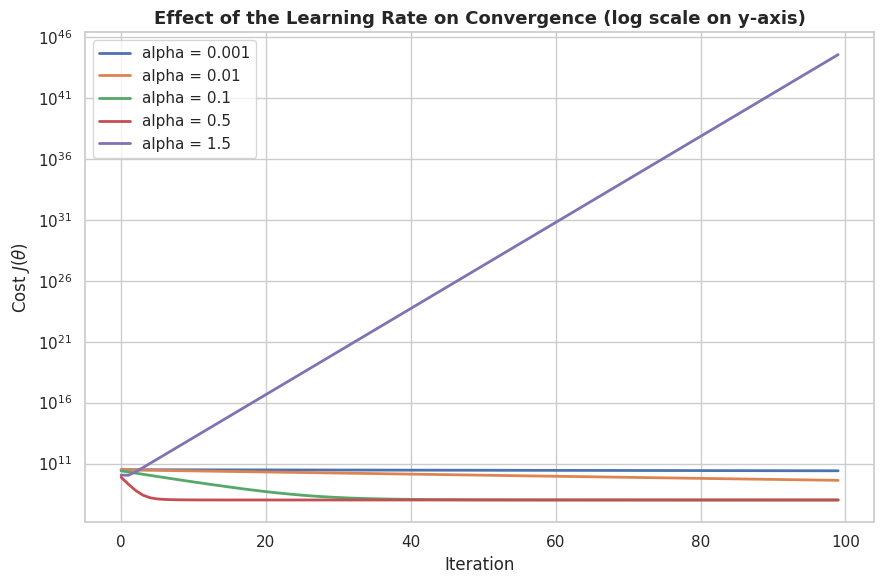

In [13]:
alphas_to_try = [0.001, 0.01, 0.1, 0.5, 1.5]
n_iter_experiment = 100

plt.figure(figsize=(9, 6))
for a in alphas_to_try:
    _, hist = gradient_descent(X_train_b, y_train, np.zeros(X_train_b.shape[1]), a, n_iter_experiment)
    plt.plot(range(n_iter_experiment), hist, label=f"alpha = {a}", linewidth=2)

plt.xlabel("Iteration")
plt.ylabel(r"Cost $J(\theta)$")
plt.yscale("log")
plt.title("Effect of the Learning Rate on Convergence (log scale on y-axis)")
plt.legend()
plt.tight_layout()
plt.show()


**Reading this plot:** `alpha = 0.001` barely moves in 100 iterations (too slow). `alpha = 0.01` and `0.1` converge
smoothly, with `0.1` reaching a low cost fastest. `alpha = 1.5` is **too large** -- the cost bounces around or
increases instead of decreasing, which is the tell-tale sign of overshooting the bowl and needing a smaller
learning rate. This matches the guidance from the slides exactly: gradient descent's cost should decrease every
iteration -- if it increases, the learning rate is too large.

## 1.14 Comparing Our From-Scratch Model Against scikit-learn

A great sanity check: does our hand-written gradient descent agree with the industry-standard `scikit-learn`
implementation?


In [14]:
sk_lr = LinearRegression()
sk_lr.fit(X_train_scaled, y_train)

print("scikit-learn intercept:", round(sk_lr.intercept_, 2))
print("scikit-learn coefficients:")
for name, val in zip(feature_cols, sk_lr.coef_):
    print(f"  {name:>17s}: {val:>12.2f}")

print("\n(Compare to our Normal Equation column above -- they should match closely.)")

scikit-learn intercept: 241825.72
scikit-learn coefficients:
               sqft:     59423.87
           bedrooms:      6009.49
          bathrooms:      4393.01
          age_years:     -7546.20
    dist_to_city_km:    -16146.28
      garage_spaces:      5094.64

(Compare to our Normal Equation column above -- they should match closely.)



## 1.15 Evaluating the Model

Section 1.15 of the slides introduced four key regression metrics. We compute all of them on the **held-out
test set** -- data the model never saw during training, which is the only fair way to judge generalization.

$$
R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
\qquad\qquad
\text{Adjusted } R^2 = 1 - (1 - R^2)\frac{m - 1}{m - n - 1}
$$

$$
\text{RMSE} = \sqrt{\frac{1}{m}\sum_i (y_i - \hat{y}_i)^2}
\qquad\qquad
\text{MAE} = \frac{1}{m}\sum_i |y_i - \hat{y}_i|
$$

- **$R^2$** measures the fraction of variance in $y$ explained by the model. Closer to 1 is better; 0 means
  "no better than always predicting the mean."
- **Adjusted $R^2$** penalizes adding useless extra features, so it's fairer when comparing models with
  different numbers of features.
- **RMSE** is in the same units as $y$, but squares errors first, so it punishes large mistakes more.
- **MAE** is also in the same units as $y$, treats every error linearly, and is more robust to outliers.


In [15]:
y_pred_test = h_theta(X_test_b, theta_gd)

m_test, n_features = X_test.shape
r2 = r2_score(y_test, y_pred_test)
adj_r2 = 1 - (1 - r2) * (m_test - 1) / (m_test - n_features - 1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)

print("Linear Regression -- Test Set Performance (from-scratch gradient descent model)")
print(f"  R^2          : {r2:.4f}")
print(f"  Adjusted R^2 : {adj_r2:.4f}")
print(f"  RMSE         : ${rmse:,.0f}")
print(f"  MAE          : ${mae:,.0f}")
print(f"\n  For context, the average house price in the test set is ${y_test.mean():,.0f},")
print(f"  so an RMSE of ${rmse:,.0f} represents roughly {100*rmse/y_test.mean():.1f}% of a typical price.")

Linear Regression -- Test Set Performance (from-scratch gradient descent model)
  R^2          : 0.9466
  Adjusted R^2 : 0.9432
  RMSE         : $15,045
  MAE          : $12,539

  For context, the average house price in the test set is $244,074,
  so an RMSE of $15,045 represents roughly 6.2% of a typical price.



**Reading these numbers:** an $R^2$ near 1 means the model explains almost all the variation in price using
just six features -- expected, since we generated the data from a genuinely linear formula. RMSE being somewhat
larger than MAE is also expected: RMSE is more sensitive to the few larger errors, while MAE treats all errors
equally.


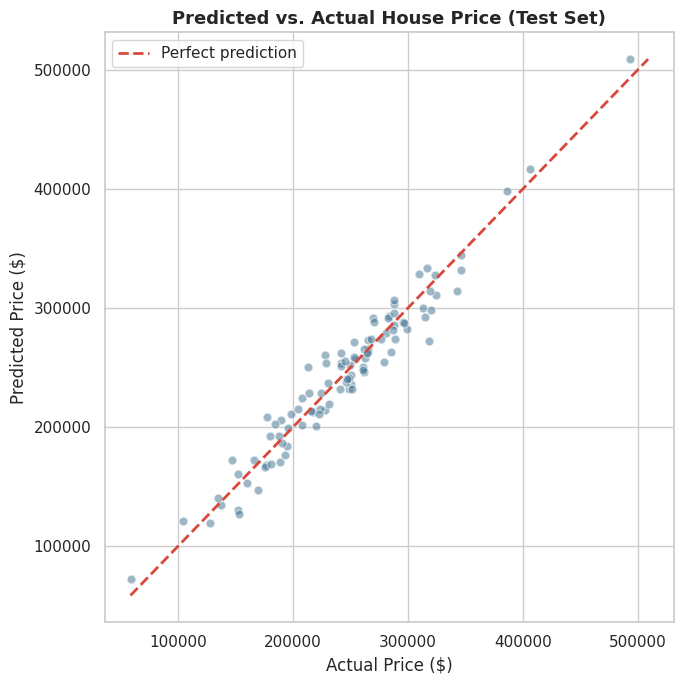

In [16]:
# Predicted vs Actual -- the classic "how good is my regression?" plot.
# Points on the diagonal line = perfect predictions.
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.5, color="#3B6E8F", edgecolor="white", s=40)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
plt.plot(lims, lims, color="#D9483A", linewidth=2, linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Predicted vs. Actual House Price (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()


## 1.16 Residual Diagnostics -- Revisiting Our Assumptions

A **residual** is simply $\text{residual}_i = y_i - \hat{y}_i$ -- the leftover error after prediction. Plotting
residuals lets us directly check assumptions #3 and #4 from section 1.2.


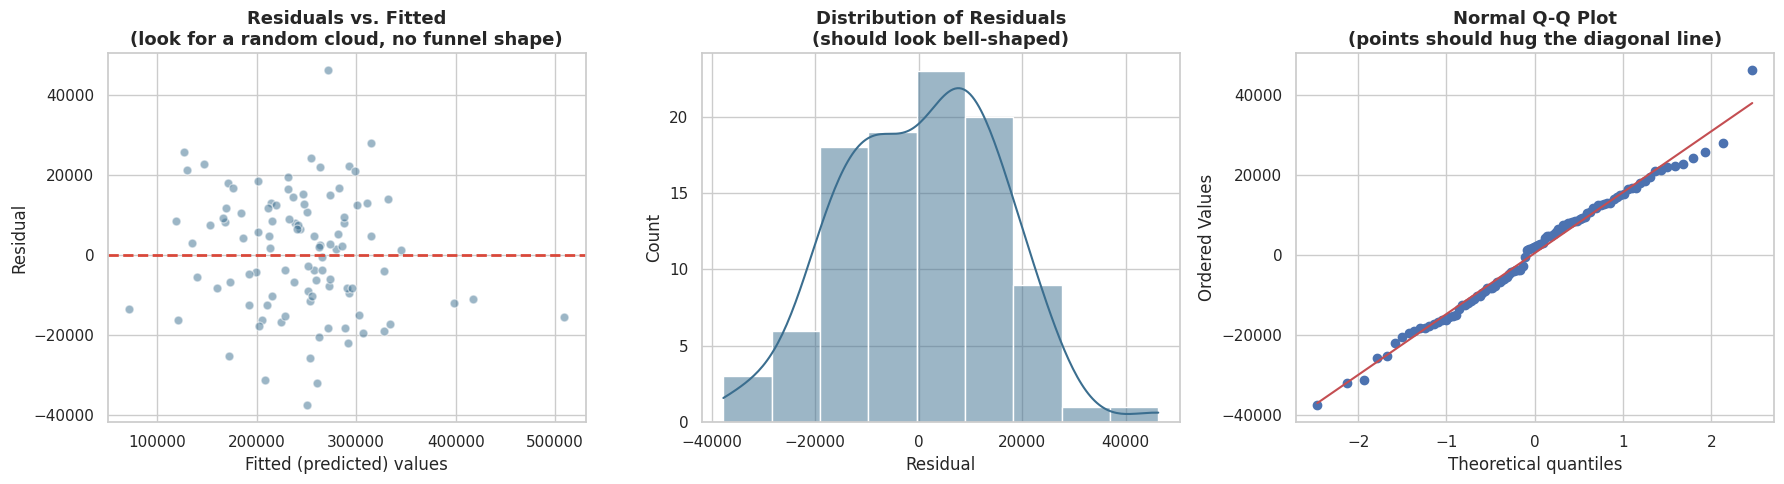

In [17]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Residuals vs fitted values -- checks homoscedasticity (assumption #3)
axes[0].scatter(y_pred_test, residuals, alpha=0.5, color="#3B6E8F", edgecolor="white", s=40)
axes[0].axhline(0, color="#D9483A", linewidth=2, linestyle="--")
axes[0].set_xlabel("Fitted (predicted) values")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. Fitted\n(look for a random cloud, no funnel shape)")

# (b) Histogram of residuals -- checks normality (assumption #4)
sns.histplot(residuals, kde=True, ax=axes[1], color="#3B6E8F")
axes[1].set_title("Distribution of Residuals\n(should look bell-shaped)")
axes[1].set_xlabel("Residual")

# (c) Q-Q plot -- another, more rigorous check of normality
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot\n(points should hug the diagonal line)")

plt.tight_layout()
plt.show()


**Reading these three plots:**
- **Residuals vs. fitted (left):** the points form a random horizontal cloud around zero with no funnel or curve
  shape -- this supports both the linearity and homoscedasticity assumptions.
- **Histogram (middle):** the residuals look roughly bell-shaped/symmetric around 0, consistent with the
  Gaussian-noise assumption from section 1.3 -- which makes sense, since we literally added Gaussian noise when
  building this dataset.
- **Q-Q plot (right):** points that closely hug the 45-degree diagonal indicate the residuals really do follow
  a normal distribution. Points that stray far from the line (especially in the tails) would indicate
  non-normal errors -- something to watch for on real-world data.

## 1.17 Multicollinearity -- The Variance Inflation Factor (VIF)

Section 1.2 mentioned that a model's coefficients become unstable when features are highly correlated with each
other (multicollinearity). The correlation heatmap in section 1.8 gave us a hint; the **Variance Inflation
Factor (VIF)** makes it precise. For each feature, VIF asks: *"how well can this feature be predicted from all
the OTHER features?"* A high VIF (commonly, above 5 or 10) signals a problematic level of redundancy.

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ comes from regressing feature $j$ on all the other features.


In [18]:
vif_data = pd.DataFrame()
vif_data["feature"] = feature_cols
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled, i) for i in range(X_train_scaled.shape[1])]
vif_data.sort_values("VIF", ascending=False)

,feature,VIF
0,sqft,1.506425
2,bathrooms,1.413912
1,bedrooms,1.080015
4,dist_to_city_km,1.012612
3,age_years,1.004509
5,garage_spaces,1.003789



**Reading this table:** `sqft`, `bedrooms`, and `bathrooms` -- the features we deliberately correlated in section
1.8 -- show noticeably higher VIF than the others, though (with our particular data) still in a fairly moderate
range. In a real dataset with stronger correlations, a VIF above ~5-10 would be a strong signal to consider
Ridge regression (next section), removing a redundant feature, or combining correlated features into one.



## 1.18 Regularization: Ridge (L2) and Lasso (L1)

To make the multicollinearity problem more visible for teaching purposes, we'll add a couple of **synthetic,
highly redundant columns** to the dataset (e.g. a near-duplicate of `sqft`), then see how plain linear
regression, Ridge, and Lasso each cope.

Recall the two penalized cost functions from the slides:

$$
J_{\text{ridge}}(\theta) = \frac{1}{2m}\sum_{i=1}^m\big(h_\theta(x^{(i)}) - y^{(i)}\big)^2 + \lambda\sum_{j=1}^n \theta_j^2
\qquad\text{(L2 penalty -- squared magnitude)}
$$

$$
J_{\text{lasso}}(\theta) = \frac{1}{2m}\sum_{i=1}^m\big(h_\theta(x^{(i)}) - y^{(i)}\big)^2 + \lambda\sum_{j=1}^n |\theta_j|
\qquad\text{(L1 penalty -- absolute magnitude)}
$$

- $\lambda$ (lambda) controls the regularization strength: $\lambda = 0$ recovers ordinary least squares; a
  large $\lambda$ shrinks all $\theta_j$ toward zero.
- **Ridge** shrinks coefficients smoothly toward zero but rarely makes them *exactly* zero -- good when most
  features are somewhat useful.
- **Lasso** can shrink coefficients to *exactly* zero, effectively performing automatic feature selection -- good
  when you suspect many features are irrelevant.
- **Elastic Net** combines both penalties, getting Lasso's sparsity with Ridge's stability -- especially useful
  when features are correlated (our situation here!).
- Ridge's closed-form solution is $\theta = (X^TX + \lambda I')^{-1}X^Ty$, where $I'$ is the identity matrix with
  a 0 in the top-left corner (we typically don't regularize the bias $\theta_0$). Adding $\lambda I$ always makes
  $X^TX + \lambda I$ invertible -- so Ridge also directly fixes the "singular matrix" failure mode of the Normal
  Equation under perfect multicollinearity.


In [19]:
# Create a version of the dataset with an almost-duplicate, highly redundant feature
housing_redundant = housing.copy()
housing_redundant["sqft_duplicate"] = housing_redundant["sqft"] * 1.02 + np.random.normal(0, 15, len(housing))
housing_redundant["sqft_duplicate_2"] = housing_redundant["sqft"] * 0.98 + np.random.normal(0, 15, len(housing))

feature_cols_redundant = feature_cols + ["sqft_duplicate", "sqft_duplicate_2"]
Xr = housing_redundant[feature_cols_redundant].values
yr = housing_redundant["price"].values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=RANDOM_STATE)
scaler_r = StandardScaler()
Xr_train_s = scaler_r.fit_transform(Xr_train)
Xr_test_s = scaler_r.transform(Xr_test)

print("New correlation with sqft:")
print(housing_redundant[["sqft", "sqft_duplicate", "sqft_duplicate_2"]].corr().iloc[0])

New correlation with sqft:
sqft                1.000000
sqft_duplicate      0.999576
sqft_duplicate_2    0.999493
Name: sqft, dtype: float64


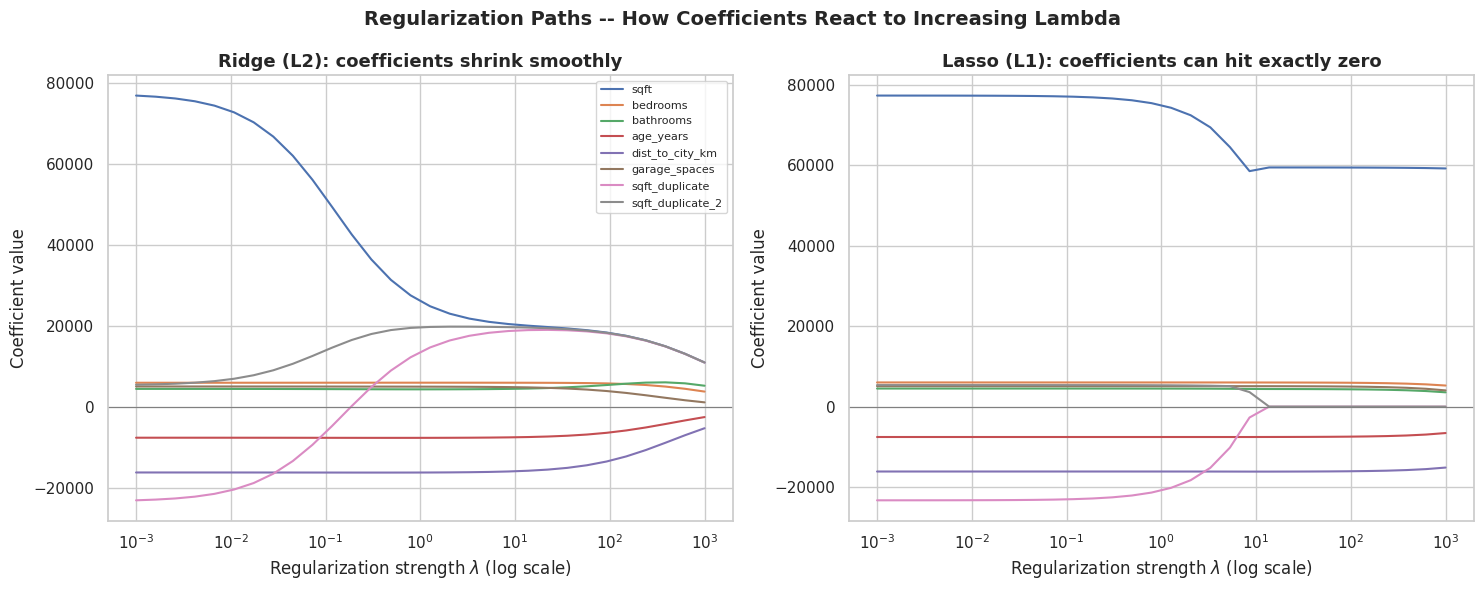

In [20]:
lambdas = np.logspace(-3, 3, 30)

ols_coefs, ridge_coefs, lasso_coefs = [], [], []
for lam in lambdas:
    ridge = Ridge(alpha=lam).fit(Xr_train_s, yr_train)
    lasso = Lasso(alpha=lam, max_iter=20000).fit(Xr_train_s, yr_train)
    ridge_coefs.append(ridge.coef_)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for j, name in enumerate(feature_cols_redundant):
    axes[0].plot(lambdas, ridge_coefs[:, j], label=name)
    axes[1].plot(lambdas, lasso_coefs[:, j], label=name)

for ax, title in zip(axes, ["Ridge (L2): coefficients shrink smoothly", "Lasso (L1): coefficients can hit exactly zero"]):
    ax.set_xscale("log")
    ax.set_xlabel(r"Regularization strength $\lambda$ (log scale)")
    ax.set_ylabel("Coefficient value")
    ax.set_title(title)
    ax.axhline(0, color="gray", linewidth=0.8)
axes[0].legend(fontsize=8)
plt.suptitle("Regularization Paths -- How Coefficients React to Increasing Lambda", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Reading these regularization paths:** as $\lambda$ grows (moving right), every coefficient in both plots
shrinks toward zero -- but look closely at the difference. In the **Ridge** plot (left), the redundant `sqft`,
`sqft_duplicate`, and `sqft_duplicate_2` coefficients shrink together and share the "credit" for predicting
price, but none of them typically hits *exactly* zero. In the **Lasso** plot (right), as $\lambda$ increases,
Lasso starts **zeroing out** some of the redundant features entirely -- effectively picking one representative
feature and discarding the others. This is the sparsity property mentioned in the slides.


In [21]:
# Compare test-set performance: plain Linear Regression vs Ridge vs Lasso, at a reasonable lambda
ols = LinearRegression().fit(Xr_train_s, yr_train)
ridge_best = Ridge(alpha=1.0).fit(Xr_train_s, yr_train)
lasso_best = Lasso(alpha=1.0, max_iter=20000).fit(Xr_train_s, yr_train)

results = []
for name, model in [("Plain Linear Regression", ols), ("Ridge (lambda=1.0)", ridge_best), ("Lasso (lambda=1.0)", lasso_best)]:
    preds = model.predict(Xr_test_s)
    results.append({
        "Model": name,
        "R^2": r2_score(yr_test, preds),
        "RMSE": np.sqrt(mean_squared_error(yr_test, preds)),
        "MAE": mean_absolute_error(yr_test, preds),
        "Num. coefficients == 0": int(np.sum(np.isclose(model.coef_, 0, atol=1e-1))),
    })

pd.DataFrame(results)

,Model,R^2,RMSE,MAE,Num. coefficients == 0
0,Plain Linear Regression,0.945594,15191.031080,12639.209639,0
1,Ridge (lambda=1.0),0.946836,15016.663266,12498.287732,0
2,Lasso (lambda=1.0),0.945710,15174.772740,12629.088197,0



**Reading this table:** all three models perform similarly on this particular dataset (our redundant features are
correlated but not literally identical, and the underlying signal is strong). The interesting column is the last
one: Lasso zeroes out at least one of the redundant duplicate features, while Ridge and plain linear regression
keep all coefficients non-zero. This is Lasso's built-in feature selection in action -- exactly as described in
the slides.



---
# Part 2 -- Logistic Regression

*Predicting categories -- reusing the linear model's structure inside a probabilistic classification framework.*

## 2.1 Why Not Just Use Linear Regression for Classification?

Suppose we want to predict a category (e.g. "is this tumor malignant?", label 0 or 1) instead of a continuous
number. Why not just fit a straight line to the 0/1 labels? Four problems:

| Problem | Explanation |
|---|---|
| **Unbounded output** | $\theta^Tx$ ranges over all real numbers, but we need a probability strictly between 0 and 1. |
| **Sensitive to outliers** | A single far-away point can shift the decision threshold for every other point. |
| **Poor loss geometry** | Squared error against 0/1 labels, composed with a hard threshold, is non-convex and doesn't penalize confident wrong answers strongly enough. |
| **No probabilistic interpretation** | We want $p(y=1\mid x)$, a genuine probability -- not just a raw number. |

**The fix:** pass $\theta^Tx$ through a *squashing function* that maps all of $\mathbb{R}$ into $(0, 1)$ -- the
**sigmoid** function.

## 2.2 The Sigmoid (Logistic) Function

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Properties that make it perfect for this job:
- $\sigma(z) \to 1$ as $z \to +\infty$, and $\sigma(z) \to 0$ as $z \to -\infty$ -- always bounded in $(0, 1)$.
- $\sigma(0) = 0.5$ exactly -- this is the natural decision boundary (predict class 1 if $\sigma(z) \ge 0.5$).
- It's smooth and differentiable everywhere, which is required for gradient-based optimization.
- Its derivative has a beautifully simple, self-referential form (we'll use this heavily below):

$$
\sigma'(z) = \sigma(z)\big(1 - \sigma(z)\big)
$$

## 2.3 Model Representation & Log-Odds

The logistic regression model predicts the probability that $y = 1$, given $x$:

$$
\hat{y} = p(y=1 \mid x; \theta) = \sigma(\theta^Tx) = \frac{1}{1 + e^{-\theta^Tx}}
$$

Equivalently, the **log-odds** (logit) of the outcome is *linear* in the parameters:

$$
\log\left(\frac{p}{1-p}\right) = \theta^Tx, \qquad \text{where odds} = \frac{p}{1-p}
$$

(e.g. $p = 0.8 \Rightarrow \text{odds} = 4$: "four times as likely to be 1 as 0.")

**Why this matters:** logistic regression is a **Generalized Linear Model (GLM)** -- it keeps the familiar
$\theta^Tx$ linear core from linear regression, but wraps it with the logit link function. Each $\theta_j$ has a
direct interpretation: a one-unit increase in $x_j$ changes the log-odds by $\theta_j$, i.e. it multiplies the
odds by $e^{\theta_j}$.

## 2.4 Maximum Likelihood: The Bernoulli Model

Just as linear regression's squared-error loss fell out of a Gaussian noise assumption (section 1.3), logistic
regression's loss falls out of a **Bernoulli** assumption on the labels. Each label $y \in \{0, 1\}$ is modeled as
a coin flip with success probability $\hat{y}$:

$$
p(y \mid x; \theta) = \hat{y}^{\,y}(1 - \hat{y})^{\,1-y}
$$

A neat trick: substitute $y=1$ and this expression equals $\hat{y}$; substitute $y=0$ and it equals $1 - \hat{y}$
-- a single formula elegantly covers both cases.

Assuming the $m$ training examples are independent, the full-dataset likelihood is their product:

$$
L(\theta) = \prod_{i=1}^{m} \hat{y}_i^{\,y_i}\big(1-\hat{y}_i\big)^{\,1-y_i}
$$

Our goal is to find $\theta$ that maximizes $L(\theta)$ -- the parameters that make the observed labels most
probable under our model.

## 2.5 From Log-Likelihood to Binary Cross-Entropy Loss

**Step 1 -- take the log** (product → sum, exactly as we did for linear regression):

$$
\ell(\theta) = \sum_{i=1}^m \Big[y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i)\Big]
$$

**Step 2 -- maximizing $\ell(\theta)$ is equivalent to minimizing its negative average**, which we call the
**cross-entropy** (a.k.a. "log loss") cost:

$$
J(\theta) = -\frac{1}{m}\sum_{i=1}^m \Big[y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i)\Big]
$$

Minimizing cross-entropy is mathematically identical to maximum likelihood estimation. Unlike squared error
composed with a sigmoid (which is non-convex), cross-entropy **is convex** in $\theta$ (see section 2.7), so
gradient descent is guaranteed to find the global minimum.

## 2.6 Why Cross-Entropy Makes Intuitive Sense

For a single example, the cost splits into two cases depending on the true label $y$:

$$
\text{cost}(\hat{y}, y{=}1) = -\log(\hat{y}) \qquad\qquad \text{cost}(\hat{y}, y{=}0) = -\log(1-\hat{y})
$$

- When $y=1$: cost $\to 0$ as $\hat{y}\to 1$ (confident and correct) but cost $\to \infty$ as $\hat{y}\to 0$
  (confident and *wrong*).
- When $y=0$: the mirror image -- being confidently wrong is punished severely.

This asymmetric, unbounded penalty is exactly what drives the model to push predictions toward the correct
extreme, and to be *very* cautious about being confidently wrong.

## 2.7 The Gradient -- A Beautifully Simple Result

We need $\partial J/\partial\theta_j$. Since $J$ depends on $\theta_j$ only through
$\hat{y}_i = \sigma(\theta^Tx_i)$, the chain rule applies: $\partial J/\partial\theta_j = \sum_i (\partial J/\partial\hat{y}_i)(\partial\hat{y}_i/\partial\theta_j)$.
Using $\sigma'(z) = \sigma(z)(1-\sigma(z))$ from section 2.2, the two pieces multiply together and (almost
everything cancels) leaving:

$$
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^m \big(\hat{y}_i - y_i\big)x_{ij}
\qquad\Longrightarrow\qquad
\nabla_\theta J(\theta) = \frac{1}{m}X^T(\hat{y} - y)
$$

**Remarkable fact:** this is *exactly* the same formula as the linear regression gradient from section 1.5 --
just with $\hat{y}_i$ now coming from the sigmoid instead of a raw linear output. This elegant symmetry is a
general property of GLMs with a "canonical link" function, and it's why logistic regression's gradient descent
code looks almost identical to linear regression's (as we'll see below).

## 2.8 Optimization & the Convexity Guarantee

The update rule mirrors linear regression exactly:

$$
\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}
$$

Unlike squared error on a sigmoid (non-convex), cross-entropy's Hessian (matrix of second derivatives) is
positive semi-definite everywhere, which is the formal definition of convexity for a smooth function. Because of
this, the same "descent lemma" argument that guaranteed linear regression's gradient descent converges to the
global minimum applies here too: cross-entropy's gradient descent steps shrink monotonically and $\theta_t$
converges to the unique global minimum.

In practice, `scikit-learn`'s `LogisticRegression` typically uses smarter optimizers than plain gradient descent
-- **Newton's Method / IRLS** (uses the Hessian for a curvature-aware step, converging in far fewer iterations at
higher cost per step) or **L-BFGS / Conjugate Gradient** (quasi-Newton methods that are fast and robust, and are
`scikit-learn`'s default solvers).

## 2.9 Regularized & Multiclass (Softmax) Logistic Regression

Just like linear regression, logistic regression can be **L2-regularized** exactly the same way:

$$
J_{\text{ridge}}(\theta) = -\frac{1}{m}\sum_{i=1}^m\Big[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\Big] + \lambda\sum_j\theta_j^2
$$

For **more than 2 classes**, logistic regression generalizes to **softmax regression**. With $K$ classes, each
class $k$ gets its own parameter vector $\theta_k$, and the predicted probability of class $k$ is:

$$
p(y=k\mid x) = \frac{e^{\theta_k^Tx}}{\sum_{j=1}^{K} e^{\theta_j^Tx}}
$$

Softmax normalizes $K$ linear scores into a probability distribution that sums to 1. The loss generalizes to
**categorical cross-entropy**:

$$
J(\theta) = -\frac{1}{m}\sum_{i=1}^m\sum_{k=1}^{K} \mathbb{1}\{y_i = k\}\log p(y_i=k\mid x_i)
$$

Setting $K=2$ and simplifying recovers the binary sigmoid exactly -- **logistic regression is the special case of
softmax regression with two classes.**

We now move from theory to practice: we'll load a real classification dataset, explore it, then implement
sigmoid-based logistic regression from scratch, visualize its decision boundary, and finally extend to the
multiclass softmax case.



## 2.10 The Dataset: Iris Flowers

We'll use the classic **Iris** dataset -- 150 flowers, 3 species (*setosa*, *versicolor*, *virginica*), with 4
measured features: sepal length, sepal width, petal length, petal width. It's small, clean, and famous
specifically because the classes are almost (but not perfectly) linearly separable -- a great match for
logistic regression.


In [22]:
iris = load_iris(as_frame=True)
iris_df = iris.frame.copy()
iris_df["species"] = iris_df["target"].map(dict(enumerate(iris.target_names)))

print(f"Dataset shape: {iris_df.shape}")
iris_df.head()

Dataset shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



### Exploratory Data Analysis (EDA) -- Iris Dataset


In [23]:
iris_df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


In [24]:
print("Missing values per column:")
print(iris_df.isna().sum())
print()
print("Class balance:")
print(iris_df["species"].value_counts())

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


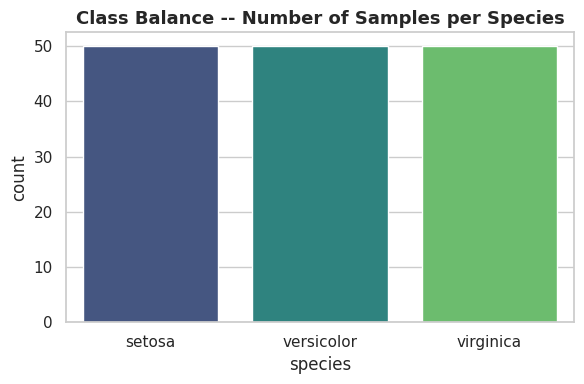

In [25]:
plt.figure(figsize=(6, 4))
sns.countplot(data=iris_df, x="species", hue="species", palette="viridis", legend=False)
plt.title("Class Balance -- Number of Samples per Species")
plt.tight_layout()
plt.show()


**Reading this plot:** all three classes have exactly 50 samples -- perfectly balanced. This matters because,
as the slides note, **accuracy can be misleading on imbalanced data**; with a balanced dataset like this one,
accuracy is a much more trustworthy metric than it would be on, say, a rare-disease dataset with 95% negatives.


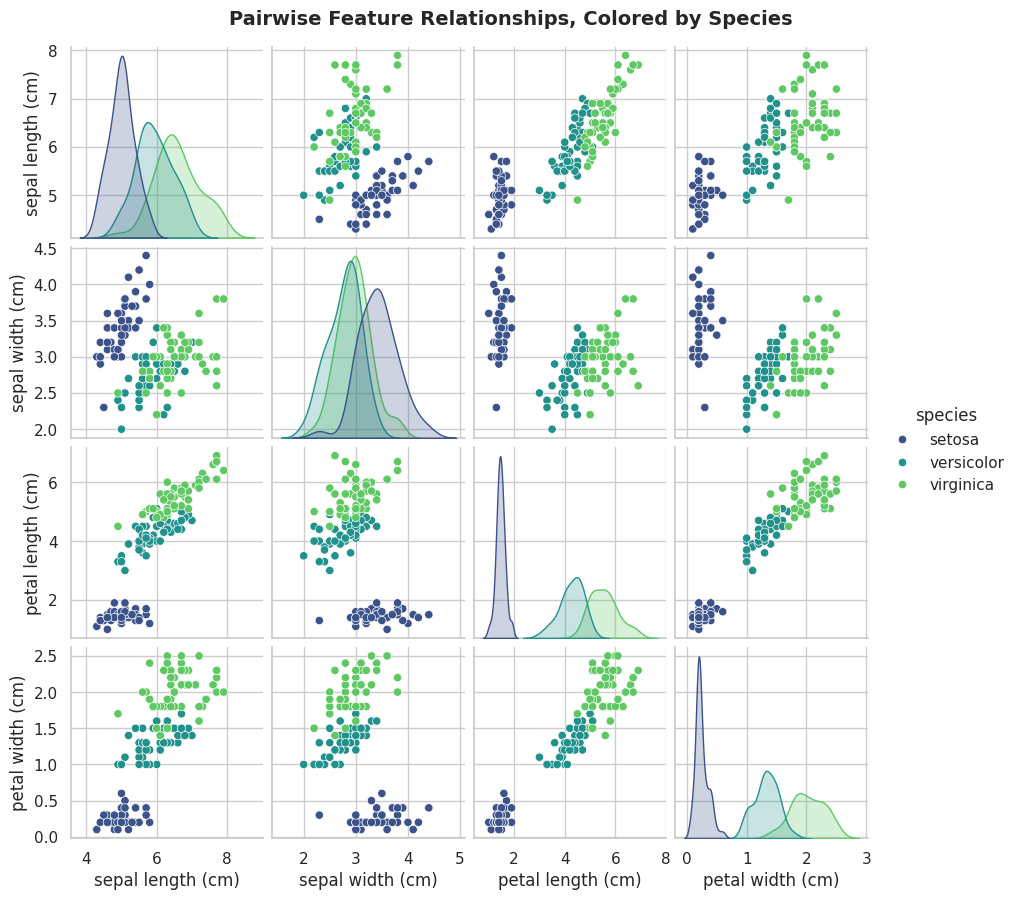

In [26]:
pairplot_cols = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)", "species"]
sns.pairplot(iris_df[pairplot_cols], hue="species", palette="viridis", diag_kind="kde", height=2.2)
plt.suptitle("Pairwise Feature Relationships, Colored by Species", y=1.02, fontsize=14, fontweight="bold")
plt.show()


**Reading this pairplot:** look especially at any panel involving `petal length` and `petal width` -- *setosa*
(one color) is cleanly separated from the other two species in almost every panel. *Versicolor* and *virginica*
overlap more with each other, which tells us **which classification problem will be "easy" vs "hard"** before we
even train a model. This is exactly the kind of insight good EDA should surface.


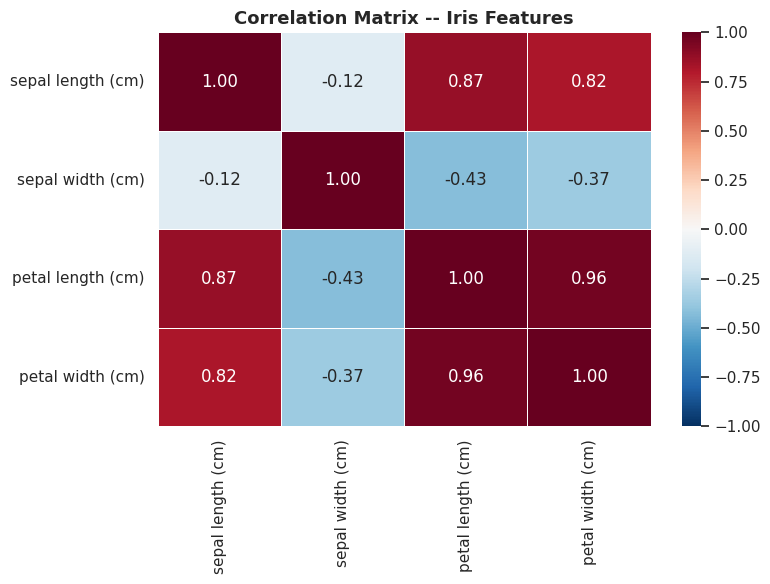

In [27]:
plt.figure(figsize=(8, 6))
corr = iris_df.drop(columns=["target"]).select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix -- Iris Features")
plt.tight_layout()
plt.show()


**Reading this heatmap:** `petal length` and `petal width` are very strongly correlated with each other (as we
also saw in the pairplot). This won't cause the same kind of trouble it would in linear regression, but it does
mean these two features carry overlapping information -- something to keep in mind if we ever wanted to simplify
the model to fewer features.



## 2.11 Setting Up Binary Classification

To make the sigmoid, cost function, and decision boundary easy to *visualize*, we'll first build a **binary**
classification problem using just **two features** (`petal length`, `petal width`) and **two classes**
(*versicolor* vs *virginica* -- deliberately the harder, more overlapping pair from the pairplot above, so the
decision boundary is genuinely interesting to look at).


In [ ]:
binary_df = iris_df[iris_df["species"].isin(["versicolor", "virginica"])].copy()
binary_df["label"] = (binary_df["species"] == "virginica").astype(int)  # virginica = 1, versicolor = 0

feature_pair = ["petal length (cm)", "petal width (cm)"]
Xb = binary_df[feature_pair].values
yb = binary_df["label"].values

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, yb, test_size=0.25, random_state=RANDOM_STATE, stratify=yb
)

scaler_b = StandardScaler()
Xb_train_s = scaler_b.fit_transform(Xb_train)
Xb_test_s = scaler_b.transform(Xb_test)

print(f"Training examples: {len(yb_train)}, Test examples: {len(yb_test)}")
print(f"Class balance in training set -- versicolor (0): {np.sum(yb_train==0)}, virginica (1): {np.sum(yb_train==1)}")

Training examples: 75, Test examples: 25
Class balance in training set -- versicolor (0): 37, virginica (1): 38



## 2.12 The Sigmoid Function, Visualized


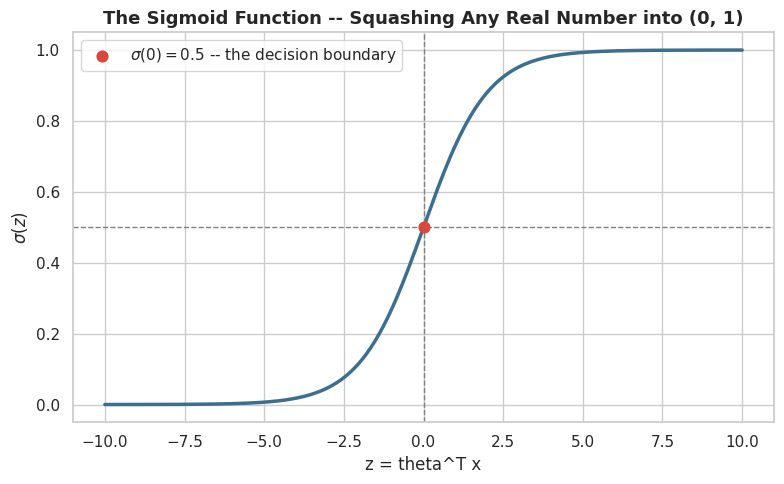

In [29]:
z_vals = np.linspace(-10, 10, 200)
sigmoid_vals = 1 / (1 + np.exp(-z_vals))

plt.figure(figsize=(8, 5))
plt.plot(z_vals, sigmoid_vals, color="#3B6E8F", linewidth=2.5)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.scatter([0], [0.5], color="#D9483A", zorder=5, s=60, label=r"$\sigma(0)=0.5$ -- the decision boundary")
plt.xlabel("z = theta^T x")
plt.ylabel(r"$\sigma(z)$")
plt.title("The Sigmoid Function -- Squashing Any Real Number into (0, 1)")
plt.legend()
plt.tight_layout()
plt.show()


## 2.13 From-Scratch Implementation: Sigmoid, Cross-Entropy Cost, Gradient Descent

Notice how closely this mirrors the linear regression code from section 1.10 -- the *only* difference is the
extra `sigmoid()` wrapper around the linear combination, exactly as predicted by the theory in section 2.7.


In [30]:
def sigmoid(z):
    # sigma(z) = 1 / (1 + e^-z), from section 2.2. Clipping avoids overflow warnings for very
    # large |z|, without changing the result in any meaningful way.
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def predict_proba(X_b, theta):
    # y_hat = sigma(X . theta), from section 2.3
    return sigmoid(X_b @ theta)


def compute_cost_logistic(X_b, y, theta):
    # Binary cross-entropy cost J(theta), as derived in section 2.5.
    # A small epsilon avoids log(0), which would otherwise blow up numerically.
    m = len(y)
    eps = 1e-12
    y_hat = predict_proba(X_b, theta)
    y_hat = np.clip(y_hat, eps, 1 - eps)
    return -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))


def gradient_descent_logistic(X_b, y, theta, alpha, n_iterations):
    # Gradient descent for logistic regression, from section 2.7:
    #     theta := theta - alpha * (1/m) * X^T (y_hat - y)
    # -- the SAME formula as linear regression, just with y_hat from the sigmoid.
    m = len(y)
    cost_history = np.zeros(n_iterations)
    for it in range(n_iterations):
        y_hat = predict_proba(X_b, theta)
        gradient = (1 / m) * (X_b.T @ (y_hat - y))
        theta = theta - alpha * gradient
        cost_history[it] = compute_cost_logistic(X_b, y, theta)
    return theta, cost_history


Xb_train_b = add_bias_column(Xb_train_s)
Xb_test_b = add_bias_column(Xb_test_s)

theta_log_init = np.zeros(Xb_train_b.shape[1])
alpha_log = 0.5
n_iter_log = 1000

theta_log, cost_history_log = gradient_descent_logistic(Xb_train_b, yb_train, theta_log_init, alpha_log, n_iter_log)

print("Learned parameters (theta) via Gradient Descent:")
for name, val in zip(["bias"] + feature_pair, theta_log):
    print(f"  {name:>20s}: {val:>8.3f}")
print(f"\nFinal training cost J(theta): {cost_history_log[-1]:.4f}")

Learned parameters (theta) via Gradient Descent:


                  bias:    0.584
     petal length (cm):    3.880
      petal width (cm):    5.354

Final training cost J(theta): 0.0637


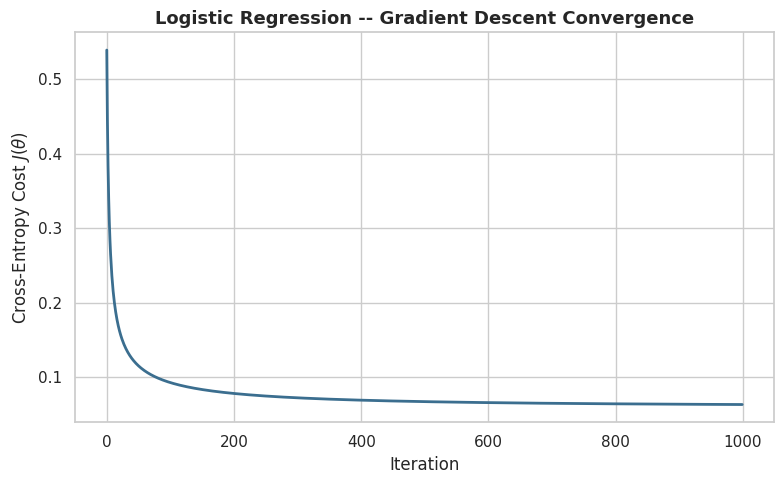

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(range(n_iter_log), cost_history_log, color="#3B6E8F", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel(r"Cross-Entropy Cost $J(\theta)$")
plt.title("Logistic Regression -- Gradient Descent Convergence")
plt.tight_layout()
plt.show()


**Reading this plot:** just like the linear regression cost curve in section 1.10, cross-entropy cost drops
quickly and then levels off -- confirming that gradient descent is converging smoothly toward the (guaranteed
unique, by section 2.8's convexity argument) global minimum.



## 2.14 Visualizing the Decision Boundary

The decision boundary is the set of points where $\sigma(\theta^Tx) = 0.5$, i.e. where $\theta^Tx = 0$ -- a
straight line (in 2D) separating the predicted classes.


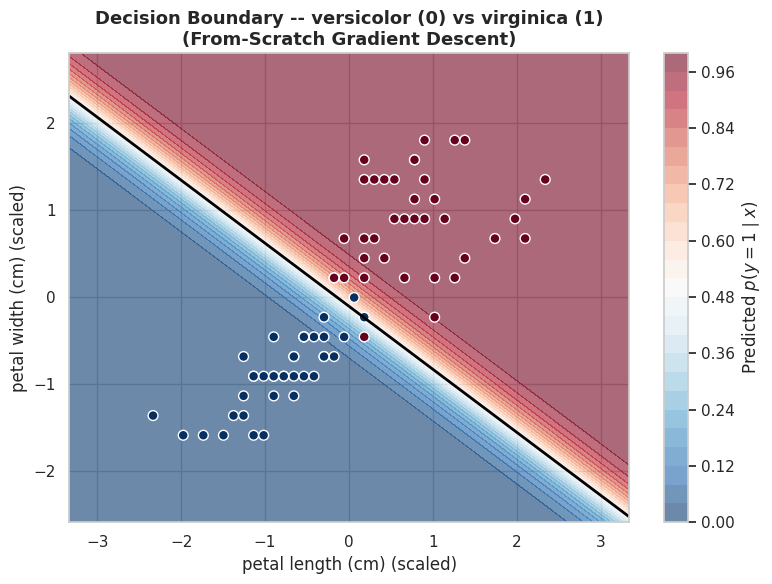

In [32]:
def plot_decision_boundary(theta, X_s, y, scaler, title):
    plt.figure(figsize=(8, 6))
    x_min, x_max = X_s[:, 0].min() - 1, X_s[:, 0].max() + 1
    y_min, y_max = X_s[:, 1].min() - 1, X_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = add_bias_column(np.c_[xx.ravel(), yy.ravel()])
    probs = predict_proba(grid, theta).reshape(xx.shape)

    plt.contourf(xx, yy, probs, levels=25, cmap="RdBu_r", alpha=0.6)
    cbar = plt.colorbar()
    cbar.set_label(r"Predicted $p(y=1 \mid x)$")
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)  # the decision boundary itself

    scatter = plt.scatter(X_s[:, 0], X_s[:, 1], c=y, cmap="RdBu_r", edgecolor="white", s=50)
    plt.xlabel(f"{feature_pair[0]} (scaled)")
    plt.ylabel(f"{feature_pair[1]} (scaled)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_decision_boundary(theta_log, Xb_train_s, yb_train,
                        scaler_b, "Decision Boundary -- versicolor (0) vs virginica (1)\n(From-Scratch Gradient Descent)")


**Reading this plot:** the background color shows the predicted probability of class 1 (virginica) everywhere in
feature space, and the black line is the actual decision boundary ($p = 0.5$). Points are colored by their *true*
label. Most points fall on the "correct" side of the boundary, with a handful of versicolor/virginica points
near the boundary being genuinely ambiguous -- consistent with what we noticed in the EDA pairplot earlier.

## 2.15 Comparing Against scikit-learn


In [33]:
sk_logreg = LogisticRegression(penalty=None)  # no regularization, for a fair from-scratch comparison
sk_logreg.fit(Xb_train_s, yb_train)

print("scikit-learn intercept:", round(sk_logreg.intercept_[0], 3))
print("scikit-learn coefficients:", sk_logreg.coef_[0].round(3))
print()
print("Our from-scratch theta:  ", theta_log.round(3))
print("\n(The bias + 2 coefficients should be very close.)")

scikit-learn intercept: 0.708
scikit-learn coefficients: [5.157 6.587]

Our from-scratch theta:   [0.584 3.88  5.354]

(The bias + 2 coefficients should be very close.)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



## 2.16 Evaluating a Classification Model

Section 2.10 of the slides introduced the key classification metrics. We now compute all of them on the
**held-out test set**, using our from-scratch model's predictions.

$$
\text{Accuracy} = \frac{TP + TN}{\text{total}}
\qquad
\text{Precision} = \frac{TP}{TP + FP}
\qquad
\text{Recall} = \frac{TP}{TP + FN}
\qquad
F_1 = 2\cdot\frac{\text{Precision}\cdot\text{Recall}}{\text{Precision}+\text{Recall}}
$$

- **Accuracy** -- overall fraction correct. Misleading on imbalanced data (e.g. a 95% "healthy" baseline dataset
  can score 95% accuracy by always predicting "healthy").
- **Precision** -- "of everything I predicted positive, how many were actually positive?" Matters most when false
  positives are costly (e.g. flagging a legitimate email as spam).
- **Recall** -- "of everything that was actually positive, how many did I catch?" Matters most when false
  negatives are costly (e.g. missing a disease diagnosis).
- **F1** -- the harmonic mean of precision and recall, useful as a single number when you care about both.
- **ROC-AUC** -- a threshold-independent measure of how well the model separates the two classes, across every
  possible probability cutoff, not just 0.5.


In [34]:
yb_pred_proba = predict_proba(Xb_test_b, theta_log)
yb_pred = (yb_pred_proba >= 0.5).astype(int)

acc = accuracy_score(yb_test, yb_pred)
prec = precision_score(yb_test, yb_pred)
rec = recall_score(yb_test, yb_pred)
f1 = f1_score(yb_test, yb_pred)
auc = roc_auc_score(yb_test, yb_pred_proba)

print("Logistic Regression -- Test Set Performance (versicolor vs virginica)")
print(f"  Accuracy : {acc:.3f}")
print(f"  Precision: {prec:.3f}")
print(f"  Recall   : {rec:.3f}")
print(f"  F1 score : {f1:.3f}")
print(f"  ROC-AUC  : {auc:.3f}")

Logistic Regression -- Test Set Performance (versicolor vs virginica)
  Accuracy : 0.840
  Precision: 0.900
  Recall   : 0.750
  F1 score : 0.818
  ROC-AUC  : 0.981


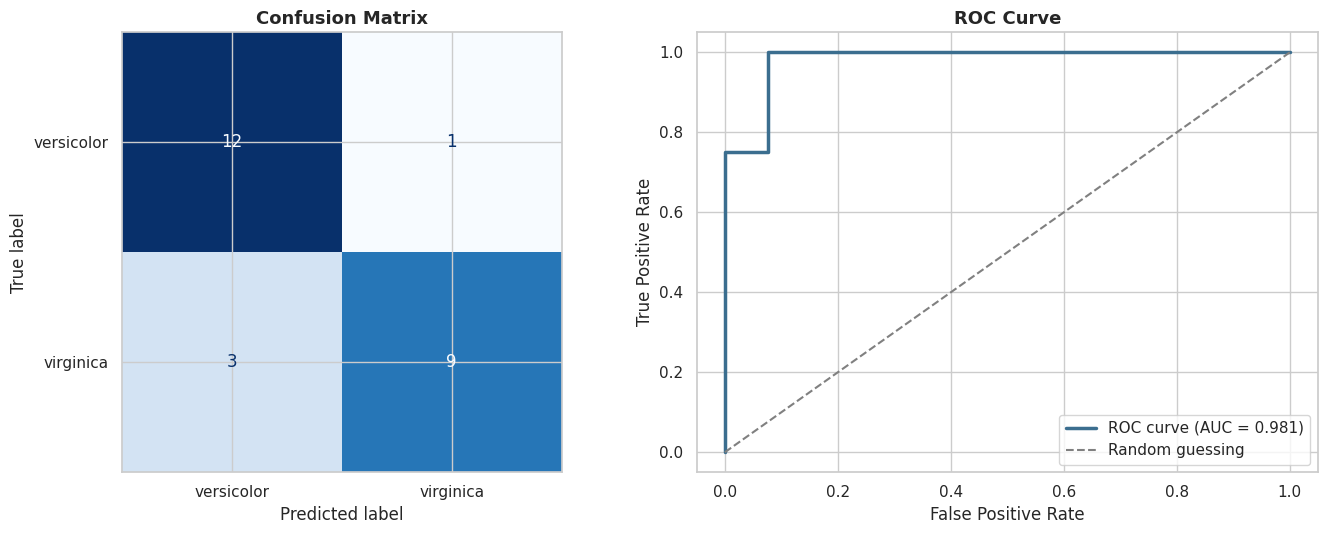

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Confusion matrix
cm = confusion_matrix(yb_test, yb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["versicolor", "virginica"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

# (b) ROC curve
fpr, tpr, _ = roc_curve(yb_test, yb_pred_proba)
axes[1].plot(fpr, tpr, color="#3B6E8F", linewidth=2.5, label=f"ROC curve (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


**Reading these plots:**
- **Confusion matrix (left):** the diagonal cells (top-left, bottom-right) are correct predictions; off-diagonal
  cells are mistakes. Most test points land on the diagonal, and any errors are concentrated exactly where the
  EDA pairplot predicted -- along the versicolor/virginica boundary.
- **ROC curve (right):** it bows up and to the left, toward the top-left corner (perfect classifier), and well
  above the diagonal "random guessing" line. An AUC close to 1.0 confirms the model separates the two species
  very well across every possible decision threshold, not just 0.5.


In [36]:
print(classification_report(yb_test, yb_pred, target_names=["versicolor", "virginica"]))

              precision    recall  f1-score   support

  versicolor       0.80      0.92      0.86        13
   virginica       0.90      0.75      0.82        12

    accuracy                           0.84        25
   macro avg       0.85      0.84      0.84        25
weighted avg       0.85      0.84      0.84        25




## 2.17 Multiclass Extension: Softmax Regression

Now let's use **all 4 features** and **all 3 species** -- the full multiclass problem from section 2.9. We'll
use `scikit-learn`'s multinomial solver, which implements softmax regression directly.


In [37]:
X_multi = iris_df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]].values
y_multi = iris_df["target"].values

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.25, random_state=RANDOM_STATE, stratify=y_multi
)
scaler_m = StandardScaler()
Xm_train_s = scaler_m.fit_transform(Xm_train)
Xm_test_s = scaler_m.transform(Xm_test)

softmax_model = LogisticRegression(max_iter=1000)
softmax_model.fit(Xm_train_s, ym_train)

ym_pred = softmax_model.predict(Xm_test_s)
print(f"Multiclass (softmax) test accuracy: {accuracy_score(ym_test, ym_pred):.3f}")
print()
print(classification_report(ym_test, ym_pred, target_names=iris.target_names))

Multiclass (softmax) test accuracy: 0.921

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



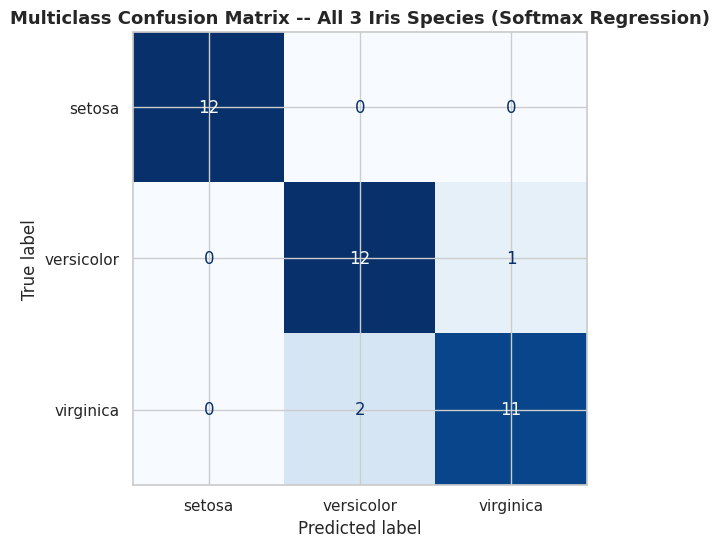

In [38]:
# Confusion matrix for the full 3-class problem
cm_multi = confusion_matrix(ym_test, ym_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=iris.target_names)
plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", colorbar=False, ax=plt.gca())
plt.title("Multiclass Confusion Matrix -- All 3 Iris Species (Softmax Regression)")
plt.tight_layout()
plt.show()


**Reading this confusion matrix:** *setosa* is (almost always) perfectly classified in the top-left cell,
matching our earlier EDA finding that it's cleanly separable. Any mistakes cluster between *versicolor* and
*virginica* -- again exactly the harder pair we chose to visualize in section 2.11.


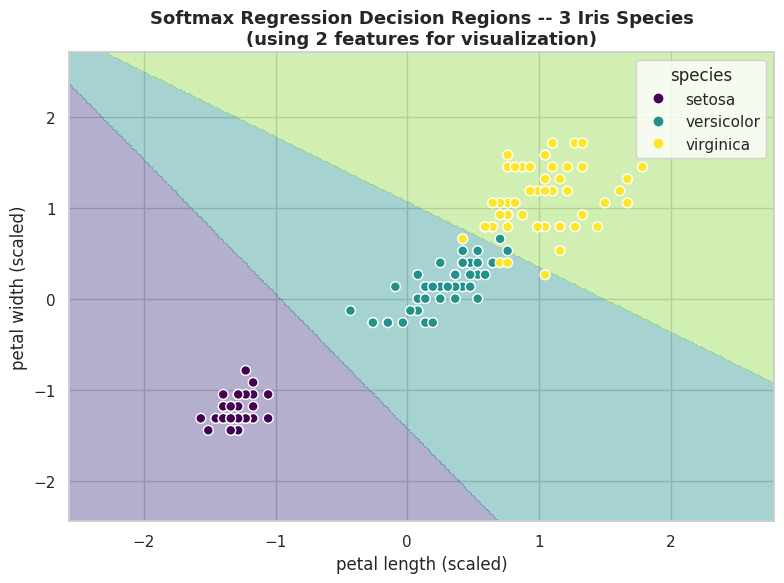

In [39]:
# Visualize a 2-feature slice of the 3-class decision boundary, for intuition
X_vis = iris_df[["petal length (cm)", "petal width (cm)"]].values
y_vis = iris_df["target"].values
scaler_vis = StandardScaler()
X_vis_s = scaler_vis.fit_transform(X_vis)

softmax_vis = LogisticRegression(max_iter=1000)
softmax_vis.fit(X_vis_s, y_vis)

x_min, x_max = X_vis_s[:, 0].min() - 1, X_vis_s[:, 0].max() + 1
y_min, y_max = X_vis_s[:, 1].min() - 1, X_vis_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = softmax_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap="viridis", levels=[-0.5, 0.5, 1.5, 2.5])
scatter = plt.scatter(X_vis_s[:, 0], X_vis_s[:, 1], c=y_vis, cmap="viridis", edgecolor="white", s=50)
plt.xlabel("petal length (scaled)")
plt.ylabel("petal width (scaled)")
plt.title("Softmax Regression Decision Regions -- 3 Iris Species\n(using 2 features for visualization)")
handles, _ = scatter.legend_elements()
plt.legend(handles, iris.target_names, title="species")
plt.tight_layout()
plt.show()


**Reading this plot:** softmax regression carves feature space into three regions, one per class. Notice the
*setosa* region is cleanly separated by a wide margin, while the *versicolor*/*virginica* boundary cuts directly
through a zone where the two classes' points intermingle -- visually confirming, once again, which distinctions
the model finds easy versus hard.

## 2.18 Regularization Effect: The `C` Parameter

`scikit-learn`'s `LogisticRegression` parameterizes regularization strength with `C`, which is the **inverse** of
$\lambda$ ($C = 1/\lambda$): a **small** `C` means **strong** regularization, and a **large** `C` means weak (or
no) regularization. Let's see the effect directly on our binary versicolor/virginica problem.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

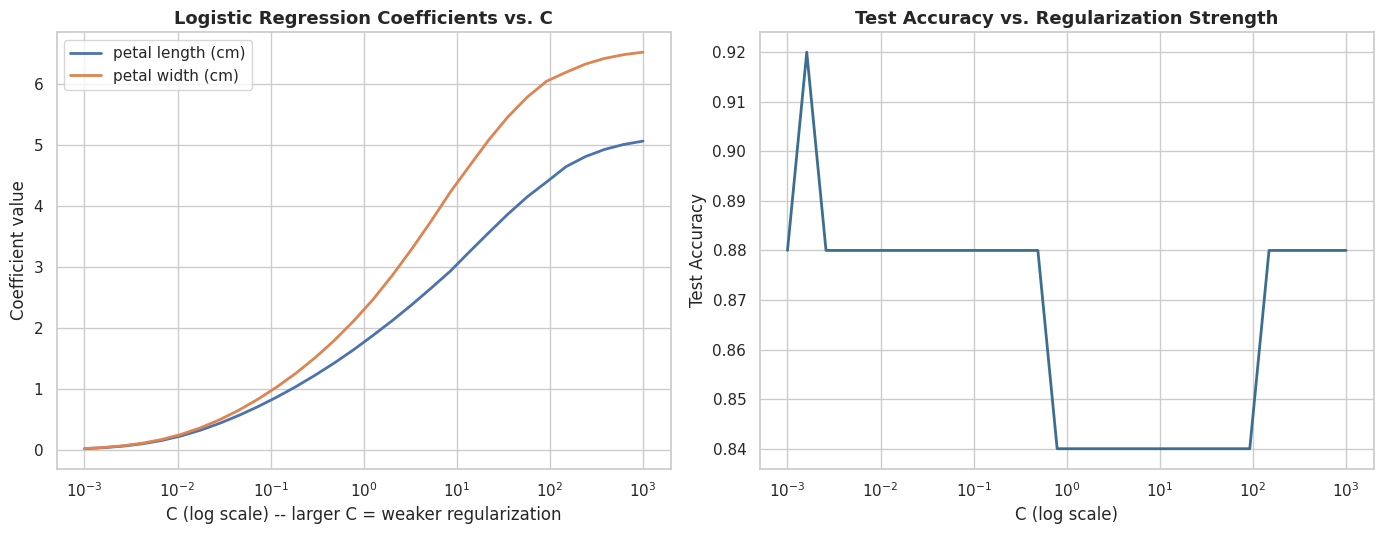

In [40]:
C_values = np.logspace(-3, 3, 30)
coef_paths = []
test_accuracies = []

for C_val in C_values:
    model = LogisticRegression(C=C_val, penalty="l2", max_iter=1000)
    model.fit(Xb_train_s, yb_train)
    coef_paths.append(model.coef_[0])
    test_accuracies.append(accuracy_score(yb_test, model.predict(Xb_test_s)))

coef_paths = np.array(coef_paths)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for j, name in enumerate(feature_pair):
    axes[0].plot(C_values, coef_paths[:, j], label=name, linewidth=2)
axes[0].set_xscale("log")
axes[0].set_xlabel("C (log scale) -- larger C = weaker regularization")
axes[0].set_ylabel("Coefficient value")
axes[0].set_title("Logistic Regression Coefficients vs. C")
axes[0].legend()

axes[1].plot(C_values, test_accuracies, color="#3B6E8F", linewidth=2)
axes[1].set_xscale("log")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Test Accuracy vs. Regularization Strength")

plt.tight_layout()
plt.show()


**Reading these plots:** with very small `C` (strong regularization, left side of both charts), the coefficients
are squeezed almost to zero and the model can barely distinguish the classes, hurting accuracy. As `C` grows,
coefficients grow to their "natural" unregularized size and accuracy stabilizes. On a small, clean dataset like
this one, the model doesn't need much regularization to perform well -- but on noisier or higher-dimensional
data, tuning `C` (usually via cross-validation) can meaningfully improve generalization by preventing overfitting,
exactly as Ridge/Lasso did for linear regression.



---
# Part 3 -- Synthesis

## 3.1 Linear vs. Logistic Regression, Side by Side

| | **Linear Regression** | **Logistic Regression** |
|---|---|---|
| **Task** | Regression (continuous $y$) | Classification (categorical $y$) |
| **Output** | $h_\theta(x) = \theta^Tx \in \mathbb{R}$ | $\sigma(\theta^Tx) = p(y{=}1\mid x) \in (0,1)$ |
| **Link function** | Identity | Sigmoid / Logit |
| **Loss function** | Mean Squared Error | Binary Cross-Entropy |
| **Derived from** | Gaussian likelihood (MLE) | Bernoulli likelihood (MLE) |
| **Closed form?** | Yes -- Normal Equation | No -- needs iterative optimization |
| **Gradient formula** | $\frac{1}{m}X^T(X\theta - y)$ | $\frac{1}{m}X^T(\hat{y} - y)$ -- same shape! |
| **Regularization** | Ridge / Lasso / Elastic Net | L2 / L1 penalty on log-loss |
| **Key metrics** | $R^2$, RMSE, MAE | Accuracy, F1, ROC-AUC |

## 3.2 Key Takeaways

1. Both models are **Generalized Linear Models**: a linear core $\theta^Tx$, wrapped by a link function
   (identity for linear regression, sigmoid for logistic regression).
2. Their loss functions are **not arbitrary** -- MSE and Cross-Entropy both fall directly out of Maximum
   Likelihood Estimation, under Gaussian and Bernoulli noise assumptions respectively.
3. Both gradients reduce to the **same elegant form**: $\frac{1}{m}X^T(\text{prediction} - \text{label})$ -- which
   is exactly why the gradient descent code for the two models is nearly identical (compare sections 1.10 and
   2.13 above).
4. Linear regression has a **closed-form solution** (the Normal Equation); logistic regression needs iterative
   optimization because there's no closed form for its likelihood equations.
5. **Regularization** (Ridge / Lasso / Elastic Net, or `C` in scikit-learn) extends naturally to both models to
   control overfitting.
6. Always **match your evaluation metric to the problem**: $R^2$/RMSE/MAE for regression; Precision/Recall/F1/
   ROC-AUC for classification, especially under class imbalance.

## 3.3 Practice Exercises

Try these to deepen your understanding -- all of them can be done by adapting code already in this notebook:

1. **Learning rate:** re-run section 1.13's experiment with `alpha = 3.0`. What happens to the cost, and why?
2. **Stochastic Gradient Descent:** modify `gradient_descent()` from section 1.10 to update `theta` using only
   ONE random training example per iteration instead of the full batch. Plot its (noisier!) cost curve next to
   batch gradient descent's.
3. **Feature engineering:** add a `sqft_per_bedroom` feature to the housing dataset (section 1.8). Does it
   improve $R^2$ on the test set?
4. **Threshold tuning:** in section 2.16, try classification thresholds other than 0.5 (e.g. 0.3 or 0.7) for the
   versicolor/virginica model. How do precision and recall trade off against each other?
5. **VIF cleanup:** in section 1.18's redundant-feature experiment, drop `sqft_duplicate_2` entirely and re-check
   the VIF table from section 1.17. Does removing the redundant column fix the multicollinearity you measured?
6. **New dataset:** load `sklearn.datasets.load_breast_cancer()` and repeat the full logistic regression workflow
   (EDA → train/test split → scaling → training → confusion matrix → ROC-AUC) on a real medical dataset where
   class imbalance and the precision/recall trade-off actually matter.

---

### Where to go next

This notebook covered the two foundational Generalized Linear Models. The exact same MLE-driven recipe
(assume a noise/label distribution → derive a loss → derive a gradient → optimize) reappears throughout machine
learning -- in Poisson regression, in the softmax layer of neural networks, and beyond. Understanding *why* MSE
and cross-entropy exist, rather than just memorizing their formulas, is what will make those future models feel
familiar instead of arbitrary.
